# 01 · Acquisition events → RFM-proxy | Santander Track DS

**Mục tiêu:** dựng R, F, M cho mỗi khách tại một tháng `as_of` (mặc định: tháng cuối của dữ liệu). Notebook chỉ giữ những gì ảnh hưởng trực tiếp đến R, F, M.

| | |
|---|---|
| **R** | số tháng từ lần *mua sản phẩm chưa có* (0→1) gần nhất đến `as_of` |
| **F** | tổng số sự kiện 0→1 đến `as_of`; `F_event_months` đếm theo tháng có event |
| **M** | (a) `M_n_products`: số sản phẩm ở `as_of`, proxy chính; (b) `M_renta`: thu nhập hộ gia đình, biến bổ trợ để đối chiếu, không phải doanh thu ngân hàng |
| **Output** | `acquisition_events.parquet`, `rfm_proxy_raw.parquet` |

**Quy tắc sự kiện:** 0→1 giữa hai tháng lịch liên tiếp của cùng khách. Snapshot đầu, tháng hụt và cặp có NaN **không** tạo sự kiện. Đây là proxy từ cờ sở hữu, không phải giao dịch.

**Nguyên tắc NaN:** phân biệt giá trị chưa xác định theo định nghĩa với dữ liệu bị thiếu. Giữ NaN và cờ trong bảng RFM proxy thô; không điền median đồng loạt cho R/F/M.

## 0. Cấu hình

In [26]:
import os, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

WORK_DIR = os.environ.get('WORK_DIR', '/kaggle/working/')
ZIP_PATH = os.environ.get('SANTANDER_ZIP')
if not ZIP_PATH:
    matches = glob.glob('/kaggle/input/**/train_ver2.csv.zip', recursive=True)
    assert len(matches) == 1, f'Cần đúng 1 ZIP nguồn, thấy: {matches}'
    ZIP_PATH = matches[0]

# Tháng chốt để tính RFM. None = tháng cuối của dữ liệu.
# Mọi R/F/M chỉ dùng dữ liệu có record_date <= AS_OF_MONTH.
AS_OF_MONTH = None

# Cohort onboarding hàng loạt phát hiện ở bước EDA trước (chỉ gắn cờ, không xóa)
ONBOARDING_MONTH = pd.Timestamp('2015-07-28')
ONBOARDING_IDX = ONBOARDING_MONTH.year * 12 + ONBOARDING_MONTH.month

# Các mốc phân vị dùng khi mô tả phân phối F, R (median, P95, P99 để nhìn outlier)
PCTS = [.25, .5, .75, .95, .99]
PCT_LABELS = {'50%': 'median', '95%': 'P95', '99%': 'P99'}

PRODUCT_MAP = {
    'ind_ahor_fin_ult1': 'prod_saving_account', 'ind_aval_fin_ult1': 'prod_guarantees',
    'ind_cco_fin_ult1': 'prod_current_account', 'ind_cder_fin_ult1': 'prod_derivada_account',
    'ind_cno_fin_ult1': 'prod_payroll_account', 'ind_ctju_fin_ult1': 'prod_junior_account',
    'ind_ctma_fin_ult1': 'prod_mas_particular_account', 'ind_ctop_fin_ult1': 'prod_particular_account',
    'ind_ctpp_fin_ult1': 'prod_particular_plus_account', 'ind_deco_fin_ult1': 'prod_short_term_deposit',
    'ind_deme_fin_ult1': 'prod_medium_term_deposit', 'ind_dela_fin_ult1': 'prod_long_term_deposit',
    'ind_ecue_fin_ult1': 'prod_eaccount', 'ind_fond_fin_ult1': 'prod_funds',
    'ind_hip_fin_ult1': 'prod_mortgage', 'ind_plan_fin_ult1': 'prod_pension_plan',
    'ind_pres_fin_ult1': 'prod_loans', 'ind_reca_fin_ult1': 'prod_taxes',
    'ind_tjcr_fin_ult1': 'prod_credit_card', 'ind_valo_fin_ult1': 'prod_securities',
    'ind_viv_fin_ult1': 'prod_home_account', 'ind_nomina_ult1': 'prod_payroll',
    'ind_nom_pens_ult1': 'prod_pension_payroll', 'ind_recibo_ult1': 'prod_direct_debit',
}
PRODUCT_COLS_RAW = list(PRODUCT_MAP)
PRODUCT_COLS = list(PRODUCT_MAP.values())
KEY_COLS = ['customer_id', 'record_date']
FAMILY = ['prod_payroll', 'prod_pension_payroll']   # hai cờ gần như trùng nhau (xem 4.2)
assert len(PRODUCT_COLS) == 24
rename_dict = {'fecha_dato': 'record_date', 'ncodpers': 'customer_id',
               'renta': 'household_income', **PRODUCT_MAP}
RAW_NEEDED_COLS = ['fecha_dato', 'ncodpers', 'renta'] + PRODUCT_COLS_RAW

---
## 1. Ingest và kiểm tra hợp đồng dữ liệu

`assert` khóa `(customer_id, record_date)` duy nhất, giá trị sản phẩm chỉ 0/1/NaN; kiểm tra tập tháng liên tục. NaN được giữ nguyên, không fill. Dữ liệu được sắp theo `(customer_id, record_date)`: các bước sau (event) dựa vào thứ tự dòng này.

In [27]:
dtype_map = {c: 'float32' for c in PRODUCT_COLS_RAW}
dtype_map.update({'ncodpers': 'int32', 'renta': 'float32'})
with zipfile.ZipFile(ZIP_PATH) as zf:
    with zf.open('train_ver2.csv') as source:
        df = pd.read_csv(source, usecols=RAW_NEEDED_COLS, dtype=dtype_map,
                         na_values=['NA', ' NA'], parse_dates=['fecha_dato'])
df = df.rename(columns=rename_dict)
df['month_idx'] = (df.record_date.dt.year * 12 + df.record_date.dt.month).astype('int32')
df = df.sort_values(['customer_id', 'record_date']).reset_index(drop=True)

assert df.customer_id.notna().all() and df.record_date.notna().all()
n_dup = df.duplicated(['customer_id', 'record_date']).sum()
assert n_dup == 0, f'{n_dup:,} khóa khách-tháng trùng'
n_bad = (~df[PRODUCT_COLS].isin([0, 1]) & df[PRODUCT_COLS].notna()).sum().sum()
assert n_bad == 0, f'{n_bad:,} giá trị sản phẩm ngoài 0/1/NaN'

FIRST_MONTH, LAST_MONTH = df.record_date.min(), df.record_date.max()
LAST_IDX = LAST_MONTH.year * 12 + LAST_MONTH.month
AS_OF = pd.Timestamp(AS_OF_MONTH) if AS_OF_MONTH else LAST_MONTH
assert AS_OF in set(df.record_date.unique()), 'AS_OF phải là một tháng có trong dữ liệu'
AS_OF_IDX = AS_OF.year * 12 + AS_OF.month

print(f'{len(df):,} dòng | {df.customer_id.nunique():,} khách | {df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'Phạm vi: {FIRST_MONTH.date()} – {LAST_MONTH.date()} | as_of = {AS_OF.date()}')

months = np.sort(df.month_idx.unique())
print(f'Số tháng: {len(months)} | liên tục: {bool((np.diff(months) == 1).all())}')

13,647,309 dòng | 956,645 khách | 1.58 GB
Phạm vi: 2015-01-28 – 2016-05-28 | as_of = 2016-05-28
Số tháng: 17 | liên tục: True


### 1.1. Cửa sổ quan sát của từng khách

**Kiểm tra gì → quyết định gì:** khách có bao nhiêu tháng, có tháng hụt không (tháng hụt làm mất cơ hội bắt event) và ai thuộc cohort 07/2015 (cần cờ riêng khi đọc F). `first_idx` là ranh giới quan sát trong dataset, không phải ngày mở tài khoản, nên tenure bị cắt trái.

In [28]:
window = (df.groupby('customer_id', sort=False)
            .agg(first_idx=('month_idx', 'min'), last_idx=('month_idx', 'max'),
                 n_months=('month_idx', 'count')).reset_index())
window['span_months'] = window.last_idx - window.first_idx + 1
window['missing_months_in_span'] = window.span_months - window.n_months
window['is_onboarding_batch'] = window.first_idx.eq(ONBOARDING_IDX)
COHORT = window.set_index('customer_id').is_onboarding_batch

print(f"Chỉ 1 tháng: {(window.n_months == 1).mean():.1%} | "
      f"có tháng hụt: {(window.missing_months_in_span > 0).mean():.1%} | "
      f"vào cohort 07/2015: {window.is_onboarding_batch.mean():.1%}")

Chỉ 1 tháng: 1.1% | có tháng hụt: 0.8% | vào cohort 07/2015: 20.2%


---
## 2. NaN nào ảnh hưởng đến R/F/M

**Kiểm tra gì → quyết định gì:** cột nào thiếu và giữ NaN thì mất bao nhiêu event. NaN ở cột sản phẩm làm cặp tháng chứa nó không xác định được event (ảnh hưởng F, R). NaN ở `renta` chỉ ảnh hưởng `M_renta`. Nếu mất ít thì giữ NaN, không cần xử lý thêm.

In [29]:
cols = KEY_COLS + PRODUCT_COLS + ['household_income']
miss = df[cols].isna().sum()
assert miss[KEY_COLS].sum() == 0, 'Khóa bị NaN: dừng lại'
raw_tbl = pd.DataFrame({'n_missing': miss, 'pct_missing': (miss / len(df) * 100).round(3)})
print(f'{int((miss == 0).sum())}/{len(miss)} cột không thiếu. Các cột có thiếu:')
display(raw_tbl[raw_tbl.n_missing > 0].sort_values('n_missing', ascending=False))

PROD_NAN_COLS = [c for c in PRODUCT_COLS if df[c].isna().any()]
print('Cột sản phẩm có NaN:', PROD_NAN_COLS or '(không có)')
if PROD_NAN_COLS:
    nan_months = df.loc[df[PROD_NAN_COLS].isna().any(axis=1), 'record_date'].dt.strftime('%Y-%m').unique()
    print('Tháng có NaN sản phẩm:', ', '.join(sorted(nan_months)))

g = df.groupby('customer_id', sort=False)
consecutive = (df.month_idx - g.month_idx.shift()).eq(1)
n_pairs = int(consecutive.sum())
if PROD_NAN_COLS:
    rows = []
    for c in PROD_NAN_COLS:
        undetermined = consecutive & (g[c].shift().isna() | df[c].isna())
        rows.append((c, int(undetermined.sum()), undetermined.sum() / n_pairs * 100))
    display(pd.DataFrame(rows, columns=['cot', 'cap_khong_xac_dinh', 'pct_tren_tong_cap']).round(4))
    any_nan_customers = df.loc[df[PROD_NAN_COLS].isna().any(axis=1), 'customer_id'].nunique()
    print(f'Tổng cặp tháng liền kề: {n_pairs:,} | khách có ≥1 NaN sản phẩm: {any_nan_customers:,} '
          f'({any_nan_customers / df.customer_id.nunique():.2%})')
else:
    print('Không có NaN ở cột sản phẩm: không mất event nào.')
del g, consecutive

24/27 cột không thiếu. Các cột có thiếu:


,n_missing,pct_missing
household_income,2794375,20.476
prod_payroll,16063,0.118
prod_pension_payroll,16063,0.118


Cột sản phẩm có NaN: ['prod_payroll', 'prod_pension_payroll']
Tháng có NaN sản phẩm: 2015-01, 2015-02, 2015-03, 2015-04, 2015-05, 2015-06


,cot,cap_khong_xac_dinh,pct_tren_tong_cap
0,prod_payroll,12837,0.1012
1,prod_pension_payroll,12837,0.1012


Tổng cặp tháng liền kề: 12,682,421 | khách có ≥1 NaN sản phẩm: 6,268 (0.66%)


Quyết định rút ra: 
- giữ NaN ở cột sản phẩm. 
- Với household_income, chưa vội kết luận, phải xem nhóm thiếu renta có khác nhóm còn lại về F và số sản phẩm không trước khi quyết định có fill ở lớp feature hay không.

---
## 3. Acquisition event (0→1)

Chỉ so hai **tháng lịch liền kề**. Hai sản phẩm đổi cùng tháng tạo 2 dòng. Mỗi event giữ thêm cột `row` (vị trí dòng trong `df`) để đối chiếu ngược với `df`. Test dữ liệu giả chạy trước khi áp dụng lên dữ liệu thật.

In [30]:
def build_acquisition_events(snapshots, product_cols):
    s = snapshots.sort_values(['customer_id', 'record_date']).reset_index(drop=True)
    g = s.groupby('customer_id', sort=False)
    gap = s['month_idx'] - g['month_idx'].shift()
    prev = g[product_cols].shift()
    consecutive = gap.eq(1).to_numpy()[:, None]
    mask = (prev.eq(0) & s[product_cols].eq(1)).to_numpy() & consecutive
    rows, cols = np.nonzero(mask)
    out = s.iloc[rows][['customer_id', 'record_date', 'month_idx']].copy()
    out['row'] = rows                                   # vị trí dòng trong snapshots đã sắp
    out['product'] = np.asarray(product_cols, dtype=object)[cols]
    return out.sort_values(['customer_id', 'record_date', 'product']).reset_index(drop=True)


def make_toy(rows, cols):
    t = pd.DataFrame(rows, columns=['customer_id', 'month_idx'] + cols)
    t['record_date'] = pd.to_datetime([f'{(m - 1) // 12}-{(m - 1) % 12 + 1:02d}-28' for m in t.month_idx])
    return t


# Unit test: 2 sản phẩm cùng tháng, NaN, tháng hụt, 1→0→1, snapshot đầu đã có sản phẩm
toy = pd.DataFrame([
    (1, '2015-01-28', 0, 0, np.nan),
    (1, '2015-02-28', 1, 1, 1),        # A,B: 0→1 (C: prev NaN → bỏ)
    (1, '2015-04-28', 0, 1, 1),        # hụt tháng 3 → không tính
    (1, '2015-05-28', 1, 0, 1),        # A: 0→1
    (2, '2015-01-28', 1, 0, 0),        # A có sẵn ở snapshot đầu → không phải event
    (2, '2015-02-28', 0, 0, 0),
    (2, '2015-03-28', 1, 0, 0),        # A: 0→1 (mua lại)
], columns=['customer_id', 'record_date', 'A', 'B', 'C'])
toy['record_date'] = pd.to_datetime(toy.record_date)
toy['month_idx'] = toy.record_date.dt.year * 12 + toy.record_date.dt.month
toy_ev = build_acquisition_events(toy, ['A', 'B', 'C'])
got = set(toy_ev[['customer_id', 'record_date', 'product']].itertuples(index=False, name=None))
assert got == {(1, pd.Timestamp('2015-02-28'), 'A'), (1, pd.Timestamp('2015-02-28'), 'B'),
               (1, pd.Timestamp('2015-05-28'), 'A'), (2, pd.Timestamp('2015-03-28'), 'A')}
print('PASS: test event (NaN, tháng hụt, nhiều sản phẩm cùng tháng, snapshot đầu)')

PASS: test event (NaN, tháng hụt, nhiều sản phẩm cùng tháng, snapshot đầu)


In [31]:
events = build_acquisition_events(df, PRODUCT_COLS)
# `row` phải trỏ đúng dòng của df (df đã sắp cùng thứ tự với hàm build)
assert (df.customer_id.to_numpy()[events.row] == events.customer_id.to_numpy()).all()
assert (df.month_idx.to_numpy()[events.row] == events.month_idx.to_numpy()).all()
events['is_onboarding_batch'] = events.customer_id.map(COHORT).astype(bool)
print(f'{len(events):,} acquisition event | {events.customer_id.nunique():,} khách có ≥1 event')

561,710 acquisition event | 201,796 khách có ≥1 event


### 3.1. Đối chiếu độc lập

Đếm lại từng cặp tháng liền kề theo cách khác, tổng phải khớp bảng event. Nếu lệch, dừng lại, không đi tiếp sang RFM.

In [32]:
def count_transitions_full(snapshots, product_cols, before, after):
    counts = pd.Series(0, index=product_cols, dtype='int64')
    by_month = {m: g.set_index('customer_id')[product_cols]
                for m, g in snapshots.groupby('month_idx')}
    ms = sorted(by_month)
    for p, c in zip(ms[:-1], ms[1:]):
        if c - p != 1:
            continue
        common = by_month[p].index.intersection(by_month[c].index)
        counts += (by_month[p].loc[common].eq(before) & by_month[c].loc[common].eq(after)).sum()
    return counts

full = count_transitions_full(df, PRODUCT_COLS, 0, 1)
assert len(events) == int(full.sum()), (len(events), int(full.sum()))
assert not events.duplicated(['customer_id', 'record_date', 'product']).any()
assert events.record_date.gt(FIRST_MONTH).all()
print(f'PASS: đếm độc lập khớp {len(events):,} event')

PASS: đếm độc lập khớp 561,710 event


---
## 4. Định nghĩa F

Hai nguồn đếm trùng có thể làm F phình lên: mua nhiều sản phẩm cùng tháng (4.1) và hai cờ payroll gần như là một (4.2). Mục này chỉ đo, không đổi event gốc.

### 4.1. Đếm F theo sự kiện hay theo tháng có sự kiện
**Kiểm tra gì → quyết định gì:** khi mua 2 sản phẩm cùng tháng, F tăng 2 hay 1? Nếu nhiều khách mua nhiều sản phẩm cùng lúc thì hai cách đếm cho kết quả rất khác → chọn định nghĩa F và ghi vào spec.

In [33]:
f_events = events.groupby('customer_id').size()
f_months = events.groupby('customer_id').month_idx.nunique()
cmp = pd.DataFrame({'F_events': f_events, 'F_event_months': f_months})
print(f"Khách có F_events > F_event_months (mua nhiều SP cùng tháng): {(cmp.F_events > cmp.F_event_months).mean():.1%}")
print(cmp.describe(percentiles=PCTS).round(2).rename(index=PCT_LABELS))

Khách có F_events > F_event_months (mua nhiều SP cùng tháng): 28.2%
         F_events  F_event_months
count   201796.00       201796.00
mean         2.78            2.21
std          2.24            1.52
min          1.00            1.00
25%          1.00            1.00
median       2.00            2.00
75%          4.00            3.00
P95          7.00            5.00
P99         11.00            7.00
max         22.00           14.00



**Nhận xét:**

1. **Đa số khách mua ít.** Có 25% khách chỉ có 1 event, median là 2. Khách điển hình chỉ mua thêm sản phẩm 1-2 lần trong cả cửa sổ quan sát.
2. **F lệch phải.** Mean (2,78) lớn hơn median (2) vì một nhóm nhỏ khách có F cao kéo trung bình lên. Vì vậy nên dùng median hoặc phân vị để mô tả F, không dùng mean.
3. **Đuôi tăng đều, không có outlier cực đoan.** P95 = 7, P99 = 11, max = 22. Max chỉ gấp đôi P99 và không có giá trị nào tách hẳn ra xa. Khi chia tier có thể chặn F ở P99 (= 11) để nhóm đuôi không kéo lệch các mốc.
4. **28,2% khách từng mua nhiều sản phẩm trong cùng một tháng**, nên `F_events` lớn hơn `F_event_months` ở nhóm này.
5. **Hai cách đếm khác nhau nhiều nhất ở đuôi.** Median bằng nhau (2 và 2), nhưng P99 là 11 so với 7 và max là 22 so với 14. Nhóm khách F cao là nhóm hay mở nhiều sản phẩm cùng lúc.

**Quyết định:** dùng `F_event_months` làm F chính, vì nó đếm "số lần khách đến mua" (một tháng có mua tính là một lần) và không tính trùng với M (số sản phẩm, `M_n_products`). Lưu ý đây là proxy từ cờ sở hữu theo tháng, không phải số giao dịch thật.

### 4.2. `prod_payroll` và `prod_pension_payroll`
**Kiểm tra gì → quyết định gì:** nếu hai cờ gần như luôn đổi cùng lúc thì mỗi lần "mua payroll" bị đếm hai lần trong F. Đo mức trùng NaN, mức trùng sở hữu, thứ tự event đầu tiên, và F đổi bao nhiêu nếu gộp thành một "payroll family" theo (khách, tháng).

In [34]:
a, b = FAMILY
print('NaN trùng khớp giữa hai cột (hàng: payroll NaN, cột: pension NaN):')
print(pd.crosstab(df[a].isna(), df[b].isna()))
print(f'Số dòng (mọi tháng) có payroll=1 mà pension=0: {int(((df[a] == 1) & (df[b] == 0)).sum()):,}')

now = df[df.month_idx.eq(AS_OF_IDX)]
ct = pd.crosstab(now[a], now[b]); display(ct)
n11 = ct.loc[1, 1]
print(f'P(pension=1 | payroll=1) = {n11 / ct.loc[1].sum():.3f}')
print(f'P(payroll=1 | pension=1) = {n11 / ct[1].sum():.3f}')
print(f'Jaccard = {n11 / (ct.values.sum() - ct.loc[0, 0]):.3f}')

first = (events[events['product'].isin(FAMILY)]
         .pivot_table(index='customer_id', columns='product', values='month_idx', aggfunc='min')
         .dropna())
lag = first[b] - first[a]        # âm: pension trước; dương: payroll trước
print(f'Khách có cả hai event: {len(first):,}')
print(f'Cùng tháng: {(lag == 0).mean():.1%} | pension trước: {(lag < 0).mean():.1%} | payroll trước: {(lag > 0).mean():.1%}')

ev = events.copy()
ev['fam'] = ev['product'].where(~ev['product'].isin(FAMILY), 'payroll_family')
F_merge = ev.drop_duplicates(['customer_id', 'month_idx', 'fam']).groupby('customer_id').size()
F_raw = events.groupby('customer_id').size()
c = pd.DataFrame({'F_raw': F_raw, 'F_merge': F_merge}).fillna(0)
print(f'Khách đổi F nếu gộp payroll family: {(c.F_raw != c.F_merge).mean():.1%} | F trung bình: {c.F_raw.mean():.2f} → {c.F_merge.mean():.2f}')
del ev, c

NaN trùng khớp giữa hai cột (hàng: payroll NaN, cột: pension NaN):
prod_pension_payroll     False  True 
prod_payroll                         
False                 13631246      0
True                         0  16063
Số dòng (mọi tháng) có payroll=1 mà pension=0: 0


prod_pension_payroll,0.0,1.0
prod_payroll,,
0.0,878605,4539
1.0,0,48309


P(pension=1 | payroll=1) = 1.000
P(payroll=1 | pension=1) = 0.914
Jaccard = 0.914
Khách có cả hai event: 43,989
Cùng tháng: 98.8% | pension trước: 0.7% | payroll trước: 0.5%
Khách đổi F nếu gộp payroll family: 21.6% | F trung bình: 2.78 → 2.42



**Nhận xét:**

1. **`prod_payroll` nằm trọn trong `prod_pension_payroll`.** Không có dòng nào có payroll = 1 mà pension = 0, nên P(pension = 1 | payroll = 1) = 1,000. Tại `as_of` có 48.309 khách giữ cả hai cờ, 4.539 khách chỉ giữ pension và không ai chỉ giữ payroll. Chiều ngược lại P(payroll = 1 | pension = 1) = 0,914, bằng đúng Jaccard.
2. **Hai cờ gần như luôn đổi cùng lúc.** Trong 43.989 khách có event của cả hai, 98,8% mua cả hai trong cùng một tháng. Chỉ 0,7% mua pension trước và 0,5% mua payroll trước.
3. **NaN của hai cột trùng khít.** Có đúng 16.063 dòng thiếu ở cả hai cột và không có dòng nào chỉ thiếu một cột. Không thể suy cột này từ cột kia, nên giữ NaN như quyết định ở mục NaN.
4. **F thô bị thổi phồng.** Mỗi lần mở payroll bị đếm thành 2 event. Nếu gộp thành một payroll family, F đổi ở 21,6% khách và F trung bình giảm từ 2,78 xuống 2,42. Tỷ lệ này khớp với nhóm 98,8% mua cùng tháng ở điểm 2.
5. **`F_event_months` không bị ảnh hưởng.** Nó đếm số tháng khác nhau có event. Hai event payroll nằm cùng tháng nên gộp hay không gộp thì số tháng vẫn như cũ.
6. **`M_n_products` có thể bị tính dư 1 sản phẩm ở nhóm giữ cả hai cờ** (48.309 khách tại `as_of`), vì số sản phẩm là tổng của 24 cờ. Đây là suy luận từ cách cộng, chưa được kiểm tra bằng bản đã gộp.

**Quyết định:** dùng `F_event_months` làm F chính nên không cần gộp thêm. Với M, giữ `M_n_products` như hiện tại và ghi chú giới hạn ở điểm 6, hoặc tính thêm một bản đã gộp payroll family để so sánh.

---
## 5. Dựng RFM-proxy tại `as_of`

- Chỉ dùng event có `month_idx <= as_of` (không rò rỉ tương lai).
- Chỉ giữ khách **có snapshot đúng tháng `as_of`** (M cần snapshot đó; khách không còn ở `as_of` không nằm trong bài toán dự đoán tháng sau).
- Khách F = 0: `R = NaN` (chưa từng mua trong cửa sổ quan sát), `has_event = False`. Không nhét giá trị giả.
- `M_renta`: giá trị khác NaN gần nhất của chính khách đó từ đầu cửa sổ quan sát tới `as_of`. Không phải trung bình qua các tháng và không điền median.
- `M_n_products` = NaN nếu snapshot `as_of` thiếu bất kỳ cột sản phẩm nào.

In [35]:
def build_rfm(snapshots, events, product_cols, as_of_idx):
    snap = snapshots[snapshots.month_idx.le(as_of_idx)]
    now = snap[snap.month_idx.eq(as_of_idx)].copy()
    now['M_n_products'] = now[product_cols].sum(axis=1, min_count=len(product_cols))
    base = now[['customer_id', 'M_n_products']]

    ev = events[events.month_idx.le(as_of_idx)]
    g = ev.groupby('customer_id')
    ev_feat = pd.DataFrame({'F': g.size(), 'F_event_months': g.month_idx.nunique(),
                            'last_event_idx': g.month_idx.max()})

    inc = snap.groupby('customer_id').agg(first_idx=('month_idx', 'min'),
                                          M_renta=('household_income', 'last'))
    out = (base.merge(ev_feat, left_on='customer_id', right_index=True, how='left')
               .merge(inc, left_on='customer_id', right_index=True, how='left'))
    for c in ['F', 'F_event_months']:
        out[c] = out[c].fillna(0).astype('int32')
    out['has_event'] = out.F.gt(0)
    out['R'] = (as_of_idx - out.last_event_idx)                # NaN nếu chưa có event
    out['tenure_months'] = (as_of_idx - out.first_idx).astype('int32')
    out['renta_missing'] = out.M_renta.isna()
    out['as_of_month'] = pd.Timestamp(year=(as_of_idx - 1) // 12, month=(as_of_idx - 1) % 12 + 1, day=28)
    return out.drop(columns=['last_event_idx', 'first_idx'])


# Test: không rò rỉ tương lai, khách F=0, khách vắng ở as_of
M0 = 2015 * 12
toy2 = make_toy([
    (1, M0 + 1, 0, 0, 100.0), (1, M0 + 2, 1, 0, np.nan), (1, M0 + 3, 1, 1, np.nan), (1, M0 + 4, 1, 1, np.nan),
    (2, M0 + 1, 1, 0, np.nan), (2, M0 + 2, 1, 0, np.nan), (2, M0 + 3, 1, 0, np.nan), (2, M0 + 4, 1, 0, np.nan),
    (3, M0 + 1, 0, 0, 50.0), (3, M0 + 2, 1, 0, 50.0),                                   # vắng ở as_of
    (4, M0 + 1, 1, 0, np.nan), (4, M0 + 2, 0, 0, np.nan), (4, M0 + 3, 1, 0, np.nan), (4, M0 + 4, 1, 0, np.nan),
], ['A', 'B', 'household_income'])
toy2_ev = build_acquisition_events(toy2, ['A', 'B'])
r3 = build_rfm(toy2, toy2_ev, ['A', 'B'], M0 + 3).set_index('customer_id')
assert set(r3.index) == {1, 2, 4}                                # khách 3 vắng ở as_of
assert r3.loc[1, 'F'] == 2 and r3.loc[1, 'R'] == 0 and r3.loc[1, 'M_n_products'] == 2
assert r3.loc[1, 'M_renta'] == 100.0                             # renta hợp lệ gần nhất
assert r3.loc[2, 'F'] == 0 and np.isnan(r3.loc[2, 'R']) and not r3.loc[2, 'has_event']
assert r3.loc[4, 'F'] == 1 and r3.loc[4, 'R'] == 0
r2 = build_rfm(toy2, toy2_ev, ['A', 'B'], M0 + 2).set_index('customer_id')
assert r2.loc[1, 'F'] == 1                                       # event tháng 3 không rò vào as_of=tháng 2
assert r2.loc[4, 'F'] == 0                                       # event tháng 3 của khách 4 chưa tồn tại
r4 = build_rfm(toy2, toy2_ev, ['A', 'B'], M0 + 4).set_index('customer_id')
assert r4.loc[1, 'R'] == 1 and r4.loc[4, 'R'] == 1
print('PASS: test RFM (không rò rỉ tương lai, F=0, khách vắng ở as_of)')

PASS: test RFM (không rò rỉ tương lai, F=0, khách vắng ở as_of)


In [36]:
rfm = build_rfm(df, events, PRODUCT_COLS, AS_OF_IDX)
rfm = rfm.merge(window[['customer_id', 'is_onboarding_batch']], on='customer_id', how='left')
assert rfm.customer_id.is_unique
assert rfm.R.dropna().ge(0).all()
assert rfm.loc[rfm.has_event, 'R'].notna().all() and rfm.loc[~rfm.has_event, 'R'].isna().all()
print(f'{len(rfm):,} khách tại as_of = {AS_OF.date()}')

931,453 khách tại as_of = 2016-05-28


| Cột | Cách tính | Khi nào là NaN |
|---|---|---|
| `F_events` (tên ban đầu `F`, đổi ở 5.1) | số event 0→1 từ đầu đến `as_of` | không có NaN, `0` nghĩa là không thấy event |
| `F_event_months` (**F chính**) | số tháng khác nhau có event | không có NaN |
| `R` | `as_of` trừ tháng của event gần nhất | khách không có event (`F = 0`) |
| `M_n_products` | số sản phẩm khách đang giữ ở tháng `as_of` | ít nhất một cờ sản phẩm ở `as_of` chưa biết |
| `M_renta` | thu nhập hợp lệ gần nhất tính đến `as_of` | khách không có income hợp lệ nào trong lịch sử |

**Nhận xét:**

1. **Bảng RFM ít khách hơn bảng event.** Chỉ giữ khách có snapshot đúng tháng `as_of`, vì `M_n_products` cần snapshot đó. Khách đã rời đi trước `as_of` không nằm trong bài toán dự đoán tháng sau.
2. **Không dùng dữ liệu sau `as_of`.** Mọi R, F, M chỉ dựa vào event và snapshot có `month_idx <= as_of`, nên không rò rỉ tương lai. Test trên dữ liệu giả đã kiểm tra: event ở tháng sau không xuất hiện khi lùi `as_of` về tháng trước.
3. **NaN của `R` là do định nghĩa, không phải dữ liệu bị mất.** Các assert ở cell dưới xác nhận `R` thiếu đúng bằng nhóm `F = 0`, và ngược lại mọi khách có event đều có `R ≥ 0`.
4. **Cờ đi kèm** (`has_event`, `renta_missing`) giúp phân biệt "bằng 0" với "không biết" ở các bước chia tier phía sau.
5. **Đây là bảng thô:** giữ nguyên NaN, không điền median cho R, F, M. Quyết định fill hay không fill từng cột nằm ở mục NaN.

Số khách tại `as_of`: **931.453**.

### 5.1. Thống nhất định nghĩa F
**Kiểm tra gì → quyết định gì:** cột `F` do `build_rfm` tạo ra là số event thô, trong khi F chính đã chọn ở mục 4.1 là `F_event_months`. Cell dưới đổi `F` thành `F_events`, tính lại phân phối và rule tier trên F chính, và đo xem chọn nhầm cột làm đổi tier bao nhiêu khách. Từ đây cột `F` không còn trong `rfm`.

In [37]:
if 'F' in rfm.columns:
    rfm = rfm.rename(columns={'F': 'F_events'})
assert rfm.has_event.eq(rfm.F_events.gt(0)).all()
assert rfm.F_event_months.le(rfm.F_events).all()
 
fpos = rfm.loc[rfm.has_event].copy()
 
 
def f_dist(s):
    vc = s.value_counts().sort_index()
    return pd.DataFrame({'pct': (vc / len(s) * 100).round(1),
                         'cum_pct': (vc.cumsum() / len(s) * 100).round(1)})
 
 
dist = pd.concat({'F_events (thô)': f_dist(fpos.F_events),
                  'F_event_months (F chính)': f_dist(fpos.F_event_months)}, axis=1)
print('Phân phối trong nhóm F > 0 (% khách):')
display(dist.head(12))
 
print('Mốc quantile của F chính (nếu trùng nhau thì không chia quantile được):')
print(fpos.F_event_months.quantile([.2, .4, .6, .8]).to_string())
cap = int(fpos.F_event_months.quantile(0.99))
print(f'\nMốc chặn P99 của F chính = {cap}  (F thô là {int(fpos.F_events.quantile(0.99))})')
 
# Rule đề xuất, áp lên CẢ HAI định nghĩa để thấy lựa chọn F có làm đổi tier không
F_BINS, F_LABELS = [0, 1, 2, 4, np.inf], ['1', '2', '3-4', '5+']
tier_main = pd.cut(fpos.F_event_months, F_BINS, labels=F_LABELS)
tier_raw = pd.cut(fpos.F_events, F_BINS, labels=F_LABELS)
print('\nPhân bố tier F theo F chính (%):')
print((tier_main.value_counts(normalize=True).reindex(F_LABELS) * 100).round(1).to_string())
print('\nBảng chéo: hàng = tier theo F thô, cột = tier theo F chính (số khách):')
display(pd.crosstab(tier_raw, tier_main))
print(f'Khách đổi tier nếu dùng F thô thay F chính: {(tier_raw != tier_main).mean():.1%}')

Phân phối trong nhóm F > 0 (% khách):


F_events (thô)         F_event_months (F chính)        
              pct cum_pct                      pct cum_pct
1            38.7    38.7                     44.2    44.2
2            19.7    58.4                     23.4    67.7
3            13.7    72.1                     14.5    82.2
4             9.8    81.9                      8.5    90.7
5             6.4    88.3                      5.0    95.7
6             4.3    92.6                      2.4    98.1
7             2.6    95.2                      1.1    99.2
8             1.9    97.1                      0.5    99.8
9             1.0    98.1                      0.2    99.9
10            0.7    98.9                      0.1   100.0
11            0.4    99.3                      0.0   100.0
12            0.3    99.6                      0.0   100.0

Mốc quantile của F chính (nếu trùng nhau thì không chia quantile được):
0.2    1.0
0.4    1.0
0.6    2.0
0.8    3.0

Mốc chặn P99 của F chính = 7  (F thô là 11)

Phân bố tier F theo F chính (%):
F_event_months
1      44.2
2      23.4
3-4    23.0
5+      9.3

Bảng chéo: hàng = tier theo F thô, cột = tier theo F chính (số khách):


F_event_months,1,2,3-4,5+
F_events,,,,
1,76761,0,0,0
2,6974,32088,0,0
3-4,4019,12542,30205,0
5+,26,1909,15441,18522


Khách đổi tier nếu dùng F thô thay F chính: 20.6%


**Nhận xét:**

1. **F chính tập trung ở giá trị thấp hơn F thô.** F = 1 chiếm 44,2% nhóm F > 0 (F thô: 38,7%), F ≤ 3 chiếm 82,2% (F thô: 72,1%).
2. **Mốc quantile 20% và 40% cùng bằng 1, nên không chia quantile được.** Rule 1 / 2 / 3-4 / 5+ cho 44,2 / 23,4 / 23,0 / 9,3%. Đủ phân hóa: nhóm nhỏ nhất vẫn gần 10% nhóm F > 0 (khoảng 18,5 nghìn khách).
3. **Dùng F thô thay F chính sẽ xếp sai tier cho 20,6% khách có event** (khoảng 40,9 nghìn), và sai theo một chiều: F thô luôn xếp bằng hoặc cao hơn, nhiều nhất ở chuyển 3-4 → 2 (12,5 nghìn) và 5+ → 3-4 (15,4 nghìn). Nguyên nhân là mua nhiều sản phẩm cùng tháng (mục 4.1), trong đó có cặp payroll (mục 4.2).
4. **P99 của F chính là 7 (F thô: 11).** Rule có nhóm `5+` mở đầu trên nên không cần chặn; chỉ cần chặn khi dùng F dạng số (clustering, chuẩn hóa).

**Quyết định:** F chính = `F_event_months`; tier F theo rule 1 / 2 / 3-4 / 5+; `F_events` giữ lại để tham khảo và kiểm tra, không dùng chia tier. Các cell mục 6 và 7 đã đổi sang tên cột mới.

### 5.2. Cohort 07/2015: đợt hàng loạt hay khách mới bình thường?
**Kiểm tra gì → quyết định gì:** đếm số khách xuất hiện lần đầu theo tháng, tỷ lệ khách có 0 sản phẩm ngay lúc xuất hiện, và bảng chéo cohort × 0 sản phẩm tại `as_of`. Mục đích: xem cờ `is_onboarding_batch` có bắt đúng một đợt bất thường không, và nhóm 25,2% khách 0 sản phẩm chủ yếu là ai → quyết định chia tier riêng cho cohort hay chỉ giữ cờ.

Số khách xuất hiện lần đầu theo tháng (tính trên toàn bộ khách của df, tháng đầu = khách đã có sẵn):


,month,n_new,pct_zero_prod_at_arrival
first_idx,,,
24181,2015-01,625457,0.028
24182,2015-02,4468,0.036
24183,2015-03,3976,0.041
24184,2015-04,3423,0.034
24185,2015-05,3501,0.024
24186,2015-06,3217,0.020
24187,2015-07,193115,0.934
24188,2015-08,14799,0.254
24189,2015-09,23598,0.319



Tháng 07/2015: 193,115 khách | trung vị các tháng khác (không tính tháng đầu): 5,913
Ước lượng phần "khách mới bình thường" lẫn trong cờ: ~3.1% (~5,913 khách)


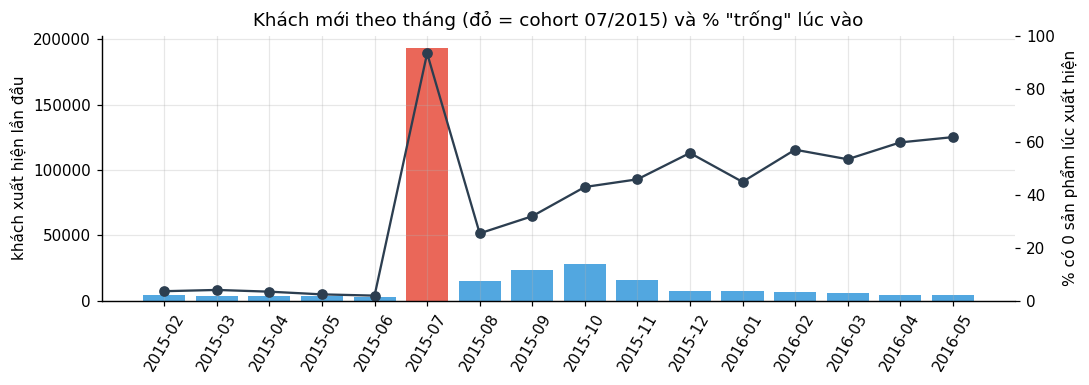


Bảng chéo tại as_of: cohort x không giữ sản phẩm nào


zero_now,False,True,All
is_onboarding_batch,,,
False,678286,62923,741209
True,18253,171991,190244
All,696539,234914,931453


Trong cohort: 90.4% giữ 0 sản phẩm ở as_of | 93.4% có 0 sản phẩm ngay lúc vào
Trong nhóm 0 sản phẩm: 73.2% thuộc cohort

Cohort tách theo "trống lúc vào" (nhóm trống mà vẫn trống = chưa bao giờ kích hoạt):


,n,pct_zero_now,pct_has_event
zero_at_arrival,,,
False,12524,0.056,0.202
True,177720,0.964,0.039


In [38]:
MONTH_LABEL = lambda i: f'{(i - 1) // 12}-{(i - 1) % 12 + 1:02d}'
FIRST_IDX = int(months.min())
 
first_rows = df.drop_duplicates('customer_id', keep='first')        # df đã sắp theo (khách, tháng)
first_info = pd.DataFrame({
    'customer_id': first_rows.customer_id.to_numpy(),
    'first_idx': first_rows.month_idx.to_numpy(),
    # NaN coi như 0 (chỉ có ở 2 cột payroll, 2015-01..06)
    'n_prod_first': first_rows[PRODUCT_COLS].sum(axis=1).to_numpy(),
})
first_info['zero_at_arrival'] = first_info.n_prod_first.eq(0)
 
by_first = first_info.groupby('first_idx').agg(
    n_new=('customer_id', 'size'), pct_zero_prod_at_arrival=('zero_at_arrival', 'mean'))
tbl = by_first.copy()
tbl.insert(0, 'month', [MONTH_LABEL(i) for i in tbl.index])
print('Số khách xuất hiện lần đầu theo tháng (tính trên toàn bộ khách của df, tháng đầu = khách đã có sẵn):')
display(tbl.round(3))
 
others = by_first.drop(index=[FIRST_IDX, ONBOARDING_IDX]).n_new
baseline = float(others.median())
n_batch = int(by_first.loc[ONBOARDING_IDX, 'n_new'])
print(f'\nTháng 07/2015: {n_batch:,} khách | trung vị các tháng khác (không tính tháng đầu): {baseline:,.0f}')
print(f'Ước lượng phần "khách mới bình thường" lẫn trong cờ: ~{baseline / n_batch:.1%} '
      f'(~{baseline:,.0f} khách)')
 
fig, ax = plt.subplots(figsize=(10, 3.6))
plot_df = by_first.drop(index=FIRST_IDX)
colors = ['#E74C3C' if i == ONBOARDING_IDX else '#3498DB' for i in plot_df.index]
ax.bar([MONTH_LABEL(i) for i in plot_df.index], plot_df.n_new, color=colors, alpha=.85)
ax.set_ylabel('khách xuất hiện lần đầu'); ax.tick_params(axis='x', rotation=60)
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot([MONTH_LABEL(i) for i in plot_df.index], plot_df.pct_zero_prod_at_arrival * 100,
         color='#2C3E50', marker='o')
ax2.set_ylabel('% có 0 sản phẩm lúc xuất hiện'); ax2.set_ylim(0, 100)
ax.set_title('Khách mới theo tháng (đỏ = cohort 07/2015) và % "trống" lúc vào')
plt.tight_layout(); plt.show()
 
r = rfm.merge(first_info, on='customer_id', how='left')
r['zero_now'] = r.M_n_products.eq(0)
print('\nBảng chéo tại as_of: cohort x không giữ sản phẩm nào')
display(pd.crosstab(r.is_onboarding_batch, r.zero_now, margins=True))
coh = r[r.is_onboarding_batch]
print(f'Trong cohort: {coh.zero_now.mean():.1%} giữ 0 sản phẩm ở as_of | '
      f'{coh.zero_at_arrival.mean():.1%} có 0 sản phẩm ngay lúc vào')
print(f'Trong nhóm 0 sản phẩm: {r.loc[r.zero_now, "is_onboarding_batch"].mean():.1%} thuộc cohort')
print('\nCohort tách theo "trống lúc vào" (nhóm trống mà vẫn trống = chưa bao giờ kích hoạt):')
display(coh.groupby('zero_at_arrival').agg(
    n=('customer_id', 'size'), pct_zero_now=('zero_now', 'mean'),
    pct_has_event=('has_event', 'mean')).round(3))

**Nhận xét:**

1. **Tháng 07/2015 là một đợt bất thường.** Có 193.115 khách xuất hiện lần đầu, gấp khoảng 33 lần trung vị các tháng khác (5.913, không tính tháng đầu), và 93,4% trong số đó không có sản phẩm nào lúc vào, so với 2-4% ở các tháng 02-06/2015. Tháng 01/2015 (625.457) là khách đã có sẵn từ đầu dữ liệu, không phải khách mới.
2. **Cờ `is_onboarding_batch` lẫn cả khách mới bình thường của tháng 7.** Ước lượng thô từ trung vị cho khoảng 3%, nhưng số này thấp vì các tháng 08-11/2015 đều cao hơn hẳn (14,8 đến 28,5 nghìn). Số chính xác hơn lấy từ `fecha_alta` ở 5.4 (khoảng 15,8 nghìn khách, tức ~8%).
3. **Hiện tượng "vào là trống" không chỉ có ở tháng 7.** Tỷ lệ khách không có sản phẩm lúc vào là 25,4% ở 08/2015 rồi tăng dần tới 61,7% ở 05/2016, trong khi 02-06/2015 chỉ 2-4%. Cờ cohort chỉ bắt được tháng 7; chưa biết khách trống vào sau đó là ai (xem 5.5).
4. **Bảng chéo:** 171.991 trong 190.244 khách cohort (90,4%) giữ 0 sản phẩm ở `as_of`, và cohort chiếm 73,2% trong 234.914 khách 0 sản phẩm. Khớp với suy luận ở 7.5 (≥ 88% và ≥ 71%). Ngoài cohort còn 62.923 khách 0 sản phẩm (8,5% nhóm ngoài cohort), chưa rõ là ai (xem 5.6).
5. **Trong cohort có hai nhóm khác hẳn nhau.** 177.720 khách trống lúc vào (96,4% vẫn trống ở `as_of`, chỉ 3,9% có event) và 12.524 khách vào đã có sản phẩm (20,2% có event). Gộp hai nhóm vào một cờ làm mờ khác biệt này.

**Quyết định:** giữ cờ `is_onboarding_batch`, không xóa cohort, nhưng không dùng nó làm phân loại duy nhất. Nguồn gốc khách được phân loại thêm ở 5.7.

### 5.3. F = 0 nhưng đang giữ sản phẩm: vì sao không có event?
**Kiểm tra gì → quyết định gì:** 504.522 khách có F = 0 nhưng đang giữ sản phẩm (mục 7.1). Mỗi khách được xếp vào đúng một lý do, theo thứ tự ưu tiên: chỉ có 1 snapshot; có sản phẩm từ snapshot đầu và có mặt từ tháng đầu; có sản phẩm ngay snapshot đầu nhưng vào sau; có tháng hụt; có cặp tháng NaN. Nhóm "chưa giải thích được" phải gần 0. Quyết định: đặt tên và tách nhóm `No_Acquisition_Event` thế nào.

In [39]:
nan_cust = set(df.loc[df[PROD_NAN_COLS].isna().any(axis=1), 'customer_id'].unique()) if PROD_NAN_COLS else set()
r = r.merge(window[['customer_id', 'missing_months_in_span']], on='customer_id', how='left')
r['joined_later'] = r.first_idx.gt(FIRST_IDX)
r['has_nan_product'] = r.customer_id.isin(nan_cust)
 
WHY_LABELS = ['1_chi_1_snapshot', '2_co_san_truoc_cua_so', '3_vao_la_da_co_san_pham',
              '4_thang_hut', '5_cap_thang_NaN']
 
 
def classify_no_event(d):
    """Thứ tự ưu tiên: mỗi khách chỉ nhận đúng 1 lý do."""
    conds = [d.tenure_months.eq(0),
             d.n_prod_first.gt(0) & ~d.joined_later,
             d.n_prod_first.gt(0) & d.joined_later,
             d.missing_months_in_span.gt(0),
             d.has_nan_product]
    return np.select(conds, WHY_LABELS, default='6_chua_giai_thich_duoc')
 
 
h = r[(~r.has_event) & r.M_n_products.gt(0)].copy()
h['why_no_event'] = classify_no_event(h)
why = h.why_no_event.value_counts().sort_index()
display(pd.DataFrame({'n_khach': why, 'pct': (why / len(h) * 100).round(1)}))
print(f'Tổng nhóm F = 0 đang giữ sản phẩm: {len(h):,}')
print('Nhóm 6 nên gần 0. Nếu lớn: định nghĩa event hoặc lý giải "có từ trước" đang thiếu một nguyên nhân.')
print('Nhóm 2 là khách cũ thật (sự kiện mua nằm ngoài cửa sổ); nhóm 3 là khách mới nhưng mua lúc mở,')
print('event đầu tiên của mỗi khách không bao giờ được bắt: F = 0 ở đây KHÔNG có nghĩa ít hoạt động.')

,n_khach,pct
why_no_event,,
1_chi_1_snapshot,1796,0.4
2_co_san_truoc_cua_so,439277,87.1
3_vao_la_da_co_san_pham,63317,12.5
4_thang_hut,132,0.0


Tổng nhóm F = 0 đang giữ sản phẩm: 504,522
Nhóm 6 nên gần 0. Nếu lớn: định nghĩa event hoặc lý giải "có từ trước" đang thiếu một nguyên nhân.
Nhóm 2 là khách cũ thật (sự kiện mua nằm ngoài cửa sổ); nhóm 3 là khách mới nhưng mua lúc mở,
event đầu tiên của mỗi khách không bao giờ được bắt: F = 0 ở đây KHÔNG có nghĩa ít hoạt động.


### 5.4. Đối chiếu bằng `fecha_alta`
**Kiểm tra gì → quyết định gì:** đọc lại file nguồn, chỉ lấy `fecha_alta`, `antiguedad`, `ind_nuevo` tại tháng `as_of` (ngày mở tài khoản thật), để kiểm chứng trực tiếp hai giả thuyết: nhóm "có từ trước cửa sổ" có thật mở trước cửa sổ không, và cohort 07/2015 có phải khách mới không.

In [40]:

AS_OF_STR = AS_OF.strftime('%Y-%m-%d')
usecols = ['fecha_dato', 'ncodpers', 'fecha_alta', 'antiguedad', 'ind_nuevo']
parts = []
with zipfile.ZipFile(ZIP_PATH) as zf, zf.open('train_ver2.csv') as src:
    for ch in pd.read_csv(src, usecols=usecols, dtype=str, na_values=['NA', ' NA'], chunksize=1_000_000):
        parts.append(ch[ch.fecha_dato.eq(AS_OF_STR)])
meta = pd.concat(parts).rename(columns={'ncodpers': 'customer_id'})
meta['customer_id'] = meta.customer_id.astype('int64')
meta = meta.drop_duplicates('customer_id')
alta = pd.to_datetime(meta.fecha_alta.str.strip(), errors='coerce')
meta['alta_idx'] = alta.dt.year * 12 + alta.dt.month
meta['antiguedad'] = pd.to_numeric(meta.antiguedad, errors='coerce').where(lambda s: s >= 0)
meta['ind_nuevo'] = pd.to_numeric(meta.ind_nuevo, errors='coerce')
meta = meta[['customer_id', 'alta_idx', 'antiguedad', 'ind_nuevo']]
del parts
 
r = r.merge(meta, on='customer_id', how='left')
print(f'fecha_alta thiếu: {r.alta_idx.isna().mean():.2%} khách (các phép so sánh dưới đây bỏ nhóm này)')
r['opened_before_window'] = r.alta_idx.lt(FIRST_IDX)
 
h = r[(~r.has_event) & r.M_n_products.gt(0)].copy()
h['why_no_event'] = classify_no_event(h)            # hàm từ cell C
ok = h.alta_idx.notna()
print('\n% khách mở tài khoản TRƯỚC cửa sổ, theo nhóm lý do F = 0 (nhóm 2 nên gần 100%, nhóm 3 gần 0%):')
display((h[ok].groupby('why_no_event').opened_before_window.mean() * 100).round(1).rename('pct_mo_truoc_cua_so'))
 
coh = r[r.is_onboarding_batch & r.alta_idx.notna()].copy()
coh['lag'] = coh.first_idx - coh.alta_idx     # số tháng từ lúc mở tài khoản đến lúc xuất hiện trong dataset
print(f'\nCohort 07/2015 (có fecha_alta): {len(coh):,} khách')
print(f'Mở tài khoản trong khoảng +-1 tháng quanh 07/2015 (khách mới thật): {coh.lag.between(-1, 1).mean():.1%}')
print(f'Mở tài khoản từ trước đó >1 tháng (khách cũ mới xuất hiện trong dataset): {(coh.lag > 1).mean():.1%}')
print('Tháng mở tài khoản phổ biến nhất của cohort:')
print(coh.alta_idx.map(MONTH_LABEL).value_counts().head(6).to_string())
print('\nind_nuevo trung bình: cohort vs còn lại')
print(r.groupby('is_onboarding_batch').ind_nuevo.mean().round(3).to_string())

fecha_alta thiếu: 0.00% khách (các phép so sánh dưới đây bỏ nhóm này)

% khách mở tài khoản TRƯỚC cửa sổ, theo nhóm lý do F = 0 (nhóm 2 nên gần 100%, nhóm 3 gần 0%):


why_no_event
1_chi_1_snapshot            5.5
2_co_san_truoc_cua_so      99.9
3_vao_la_da_co_san_pham     3.2
4_thang_hut                81.8
Name: pct_mo_truoc_cua_so, dtype: float64


Cohort 07/2015 (có fecha_alta): 190,244 khách
Mở tài khoản trong khoảng +-1 tháng quanh 07/2015 (khách mới thật): 8.9%
Mở tài khoản từ trước đó >1 tháng (khách cũ mới xuất hiện trong dataset): 91.1%
Tháng mở tài khoản phổ biến nhất của cohort:
alta_idx
2015-07    15787
2014-10     5478
2014-11     4990
2013-10     4691
2014-12     4447
2013-11     3821

ind_nuevo trung bình: cohort vs còn lại
is_onboarding_batch
False    0.046
True     0.002


**Nhận xét (mục 5.3 và 5.4):**

1. **Nhóm F = 0 đang giữ sản phẩm được giải thích hết.** 87,1% (439.277 khách) có sản phẩm từ snapshot đầu và có mặt từ tháng đầu; 12,5% (63.317) vào sau nhưng đã có sản phẩm ngay lúc vào; 0,4% chỉ có 1 snapshot; 0,03% do tháng hụt. Hai lý do còn lại (cặp NaN, chưa giải thích được) không có khách nào.
2. **Giả thuyết "đã có từ trước cửa sổ" được xác nhận.** 99,9% nhóm có sản phẩm từ trước mở tài khoản trước cửa sổ theo `fecha_alta` (`fecha_alta` thiếu 0,00% khách). F = 0 ở nhóm này nghĩa là khách cũ có event nằm ngoài dữ liệu, không phải "ít hoạt động".
3. **Nhóm "vào là đã có sản phẩm" là khách mới thật, và event mua đầu tiên của họ không bao giờ được bắt.** 96,8% nhóm này mở tài khoản trong cửa sổ (chỉ 3,2% mở trước). Họ có sản phẩm ngay snapshot đầu nên không có cặp 0→1 nào, dù thực tế đã mua. Gộp họ chung với khách cũ trong `No_Acquisition_Event` là sai ý nghĩa. Nhóm này chiếm 12,5% khách F = 0 đang giữ sản phẩm.
4. **Cohort 07/2015 không phải khách mới.** Chỉ 8,9% mở tài khoản trong khoảng ±1 tháng quanh 07/2015; 91,1% mở từ trước, tập trung ở 10-12/2013 và 10-12/2014. `ind_nuevo` trung bình 0,002 (nhóm còn lại 0,046). Kết hợp với 93,4% không có sản phẩm lúc vào (5.2): đây là khách đã đăng ký từ lâu nhưng chưa có sản phẩm, lần đầu xuất hiện trong dataset ở 07/2015. Lý do họ xuất hiện đúng tháng đó không xác định được từ dữ liệu.
5. **Số khách mới thật trong cờ cohort là khoảng 15,8 nghìn (~8,3%),** cao gấp khoảng 2,7 lần ước lượng thô ~3% ở 5.2. Dùng số từ `fecha_alta`.
6. **Tenure thật tính được cho mọi khách** (`alta_idx` không thiếu). Điều này giải quyết vấn đề tenure bị cắt trái ở 7.2; xem 7.2b.

**Quyết định:**

- `No_Acquisition_Event` tách tối thiểu thành ba nhóm: khách cũ đang giữ sản phẩm (nhóm 2), khách mới vào đã có sản phẩm (nhóm 3, cờ `opened_with_product`) và khách không giữ sản phẩm nào.
- **Không thêm event "lúc mở tài khoản" vào F.** F giữ nghĩa là số event 0→1 quan sát được, để khớp bảng event đã đối chiếu độc lập ở 3.1; thay vào đó gắn cờ và xử lý ở bước tier. Cách này đảo ngược được, còn đổi định nghĩa event thì không.
- Mô tả cohort 07/2015 là "khách đã đăng ký từ trước, xuất hiện lần đầu ở 07/2015, phần lớn chưa có sản phẩm", không gọi là "khách mới".

### 5.5. Khách xuất hiện sau tháng đầu: mới thật hay đã đăng ký từ trước?
**Kiểm tra gì → quyết định gì:** ở 5.2, tỷ lệ "trống lúc vào" tăng từ 25% (08/2015) lên 62% (05/2016). Với từng tháng xuất hiện, tách khách theo việc họ mở tài khoản sát tháng xuất hiện (mới thật, lệch ≤ 1 tháng) hay mở từ trước (đã đăng ký, mới xuất hiện), rồi xem tỷ lệ trống ở từng nhóm. Nếu khách trống phần lớn là khách mới thật thì đó là khách mới chưa kích hoạt; nếu là khách mở từ trước thì hiện tượng của cohort 07/2015 vẫn tiếp diễn sau tháng 7 và cờ cohort chưa đủ. Bảng chỉ gồm khách còn ở `as_of`.

In [41]:
a = r[(r.first_idx > FIRST_IDX) & r.alta_idx.notna()].copy()
a['lag'] = a.first_idx - a.alta_idx              # số tháng từ lúc mở tài khoản đến lúc xuất hiện
a['new_true'] = a.lag.between(-1, 1)             # mở tài khoản sát tháng xuất hiện
a['month'] = a.first_idx.map(MONTH_LABEL)

tab = a.groupby('month').agg(n=('customer_id', 'size'), pct_mo_sat_thang_vao=('new_true', 'mean'),
                             pct_trong_luc_vao=('zero_at_arrival', 'mean'))
tab['pct_trong | mo_sat'] = a[a.new_true].groupby('month').zero_at_arrival.mean()
tab['pct_trong | mo_tu_truoc'] = a[~a.new_true].groupby('month').zero_at_arrival.mean()
display(tab.round(3))

post = a[a.first_idx > ONBOARDING_IDX]
print('\nKhách xuất hiện sau 07/2015: mở tài khoản sát tháng vào x trống lúc vào')
display(pd.crosstab(post.new_true.rename('mo_sat_thang_vao'), post.zero_at_arrival.rename('trong_luc_vao'), margins=True))

,n,pct_mo_sat_thang_vao,pct_trong_luc_vao,pct_trong | mo_sat,pct_trong | mo_tu_truoc
month,,,,,
2015-02,4117,0.730,0.029,0.006,0.091
2015-03,3756,0.740,0.031,0.008,0.095
2015-04,3235,0.735,0.028,0.006,0.089
2015-05,3287,0.767,0.017,0.007,0.052
2015-06,3060,0.761,0.018,0.003,0.064
2015-07,190244,0.089,0.934,0.306,0.996
2015-08,13865,0.984,0.221,0.219,0.330
2015-09,22386,0.987,0.296,0.295,0.375
2015-10,27054,0.987,0.409,0.409,0.389



Khách xuất hiện sau 07/2015: mở tài khoản sát tháng vào x trống lúc vào


trong_luc_vao,False,True,All
mo_sat_thang_vao,,,
False,1617,1221,2838
True,65689,43345,109034
All,67306,44566,111872


### 5.6. 0 sản phẩm ngoài cohort: chưa từng kích hoạt hay đã bỏ hết?
**Kiểm tra gì → quyết định gì:** 62.923 khách 0 sản phẩm nằm ngoài cohort. Tách thành "chưa từng giữ sản phẩm nào trong dữ liệu" (chưa kích hoạt) và "từng giữ rồi về 0" (có sản phẩm ở snapshot đầu hoặc có event). Hai nhóm có ý nghĩa khác nhau cho tier M = 0: nhóm sau mới là khách rời bỏ đúng nghĩa. Giới hạn: sản phẩm chỉ giữ trong tháng hụt thì không thấy.

In [42]:
z = r[r.zero_now & ~r.is_onboarding_batch].copy()
z['ever_held'] = z.n_prod_first.gt(0) | z.has_event
z['nhom'] = np.where(z.ever_held, 'tung_giu_roi_ve_0', 'chua_tung_kich_hoat')
z['vao_luc'] = np.select([z.first_idx.eq(FIRST_IDX), z.first_idx.lt(ONBOARDING_IDX)],
                         ['co_san_tu_dau', 'vao_truoc_07_2015'], default='vao_sau_07_2015')
z['mo_sat_thang_vao'] = (z.first_idx - z.alta_idx).between(-1, 1)

zero_all = r[r.zero_now]
print(f'Nhóm 0 sản phẩm: {len(zero_all):,} = cohort {int(zero_all.is_onboarding_batch.sum()):,} '
      f'+ ngoài cohort {len(z):,}')
g = z.groupby('nhom').agg(n=('customer_id', 'size'), pct_mo_sat_thang_vao=('mo_sat_thang_vao', 'mean'),
                          tenure_quan_sat_tb=('tenure_months', 'mean'))
g['pct'] = (g.n / len(z) * 100).round(1)
display(g.round(3))
print('\nTheo thời điểm xuất hiện lần đầu:')
display(pd.crosstab(z.nhom, z.vao_luc, margins=True))

Nhóm 0 sản phẩm: 234,914 = cohort 171,991 + ngoài cohort 62,923


,n,pct_mo_sat_thang_vao,tenure_quan_sat_tb,pct
nhom,,,,
chua_tung_kich_hoat,44558,0.660,8.814,70.8
tung_giu_roi_ve_0,18365,0.253,14.074,29.2



Theo thời điểm xuất hiện lần đầu:


vao_luc,co_san_tu_dau,vao_sau_07_2015,vao_truoc_07_2015,All
nhom,,,,
chua_tung_kich_hoat,14353,30022,183,44558
tung_giu_roi_ve_0,13250,3201,1914,18365
All,27603,33223,2097,62923


### 5.7. Gộp các cột nguồn gốc khách vào `rfm`
**Kiểm tra gì → quyết định gì:** gộp các cột vừa dựng (`first_idx`, `n_prod_first`, `zero_at_arrival`, `alta_idx`, `true_tenure_months`, `opened_before_window`, `why_no_event`) vào `rfm` để lưu ra file, và định nghĩa thêm:

| `arrival_type` | Điều kiện |
|---|---|
| `legacy_from_start` | mở tài khoản trước cửa sổ và có mặt từ tháng đầu |
| `registered_earlier_seen_later` | mở tài khoản trước cửa sổ nhưng lần đầu xuất hiện sau tháng đầu (gồm phần lớn cohort 07/2015) |
| `new_in_window` | mở tài khoản trong cửa sổ |
| `unknown` | thiếu `fecha_alta` |

`opened_with_product` = `new_in_window` và có sản phẩm ngay snapshot đầu (event mua đầu tiên không được bắt). Bảng hồ sơ theo `arrival_type` cho biết các nhóm có khác nhau đủ để tier phân biệt không.

In [43]:
r['true_tenure_months'] = (AS_OF_IDX - r.alta_idx).clip(lower=0)
r['arrival_type'] = np.select(
    [r.alta_idx.isna(),
     r.opened_before_window & ~r.joined_later,
     r.opened_before_window & r.joined_later],
    ['unknown', 'legacy_from_start', 'registered_earlier_seen_later'],
    default='new_in_window')
r['opened_with_product'] = r.arrival_type.eq('new_in_window') & r.n_prod_first.gt(0)

new_cols = ['first_idx', 'n_prod_first', 'zero_at_arrival', 'alta_idx', 'true_tenure_months',
            'opened_before_window', 'arrival_type', 'opened_with_product']
assert r.customer_id.is_unique and len(r) == len(rfm)
rfm = rfm.merge(r[['customer_id'] + new_cols], on='customer_id', how='left', validate='one_to_one')
rfm['why_no_event'] = rfm.customer_id.map(h.set_index('customer_id').why_no_event)   # chỉ có giá trị cho F = 0 đang giữ sản phẩm
assert len(rfm) == len(r) and rfm.customer_id.is_unique

display(rfm.groupby('arrival_type').agg(
    n_khach=('customer_id', 'size'), pct_F_duong=('has_event', 'mean'),
    F_months_tb=('F_event_months', 'mean'), M_san_pham_tb=('M_n_products', 'mean'),
    pct_0_san_pham=('M_n_products', lambda s: s.eq(0).mean()),
    true_tenure_tb=('true_tenure_months', 'mean')).round(3))
ow = rfm[rfm.opened_with_product]
print(f'opened_with_product: {len(ow):,} khách ({len(ow) / len(rfm):.1%}) | trong đó F = 0: {(~ow.has_event).mean():.1%}')

,n_khach,pct_F_duong,F_months_tb,M_san_pham_tb,pct_0_san_pham,true_tenure_tb
arrival_type,,,,,,
legacy_from_start,609789,0.241,0.587,1.782,0.045,95.315
new_in_window,145727,0.302,0.492,0.967,0.276,7.606
registered_earlier_seen_later,175937,0.042,0.069,0.074,0.951,94.749


opened_with_product: 93,042 khách (10.0%) | trong đó F = 0: 71.7%


---
## 6. Missing ở tầng RFM

**Kiểm tra gì → quyết định gì:** NaN nào do định nghĩa RFM proxy, NaN nào do dữ liệu nguồn; nhóm thiếu `renta` có đặc điểm khác nhóm còn lại không. `F = 0` chỉ có nghĩa không quan sát thấy sự kiện 0→1 trong cửa sổ dữ liệu, không có nghĩa khách chưa từng mua sản phẩm.

| Biến | Giá trị 0/NaN có nghĩa gì? | Quyết định cho RFM proxy thô |
|---|---|---|
| `R` | `NaN` khi `F = 0`: không có sự kiện để đo | Giữ `NaN`; khi chia tier tạo nhóm `No_Acquisition_Event`, không điền median hay gán R rất lớn |
| `F` | `0`: không thấy sự kiện 0→1 hợp lệ trong cửa sổ | Giữ `0` như một giá trị hợp lệ |
| `M_n_products` | `0`: biết chắc không sở hữu sản phẩm nào; `NaN`: ít nhất một cờ sản phẩm ở `as_of` chưa biết | Giữ phân biệt 0 với `NaN`; nếu có `NaN`, tạo nhóm `Unknown` |
| `M_renta` | `NaN`: chính khách đó không có giá trị income hợp lệ nào đến `as_of` | Giữ `NaN`/`Unknown`, không điền median trong proxy thô |

In [44]:
rfm_cols = ['F_events', 'F_event_months', 'R', 'M_n_products', 'M_renta']
m = rfm[rfm_cols].isna().sum()
display(pd.DataFrame({'n_missing': m, 'pct_missing': (m / len(rfm) * 100).round(3)}))
assert rfm.F_events.notna().all() and rfm.F_event_months.notna().all()
assert rfm.R.isna().eq(~rfm.has_event).all(), 'R thiếu không khớp F=0'
assert (df.household_income.dropna() > 0).all(), 'renta ≤ 0: phải coi là thiếu'

# renta: lấy giá trị hợp lệ gần nhất có cứu thêm khách nào không?
at_asof = df.loc[df.month_idx.eq(AS_OF_IDX)].set_index('customer_id').household_income
print(f"renta thiếu tại snapshot as_of: {rfm.customer_id.map(at_asof).isna().mean():.2%} "
      f"| sau khi lấy giá trị gần nhất: {rfm.renta_missing.mean():.2%}")
n0 = rfm.M_n_products.eq(0)
print(f'n_products = 0: {int(n0.sum()):,} khách ({n0.mean():.1%})')

display(rfm.groupby('renta_missing').agg(
    n_khach=('customer_id', 'size'), pct_F_duong=('has_event', 'mean'), F_events_tb=('F_events', 'mean'), F_months_tb=('F_event_months', 'mean'),
    n_products_tb=('M_n_products', 'mean'), tenure_tb=('tenure_months', 'mean'),
    pct_cohort_0715=('is_onboarding_batch', 'mean')).round(3))

,n_missing,pct_missing
F_events,0,0.000
F_event_months,0,0.000
R,732966,78.691
M_n_products,0,0.000
M_renta,229018,24.587


renta thiếu tại snapshot as_of: 24.59% | sau khi lấy giá trị gần nhất: 24.59%
n_products = 0: 234,914 khách (25.2%)


,n_khach,pct_F_duong,F_events_tb,F_months_tb,n_products_tb,tenure_tb,pct_cohort_0715
renta_missing,,,,,,,
False,702435,0.213,0.630,0.500,1.410,14.375,0.223
True,229018,0.213,0.497,0.396,1.093,10.920,0.146



**Nhận xét:**

1. **`R` thiếu 78,7% (732.966 khách) là do định nghĩa, không phải mất dữ liệu.** Tỷ lệ này khớp với 21,3% khách có event (`pct_F_duong` = 0,213): không có event 0→1 thì không có "lần mua gần nhất". Đây là nhóm `F = 0`.
2. **`F_events`, `F_event_months` và `M_n_products` không thiếu giá trị nào.** `M_n_products` không có NaN vì `as_of` là tháng cuối, còn NaN ở cờ sản phẩm chỉ nằm trong 2015-01 đến 2015-06.
3. **`n_products = 0` có 234.914 khách (25,2%) là giá trị hợp lệ**: biết chắc khách không giữ sản phẩm nào. Không gộp nhóm này với "không biết".
4. **`M_renta` thiếu 24,59%, và lấy giá trị hợp lệ gần nhất không cứu thêm khách nào** (vẫn 24,59%). Nhóm này thiếu income trong cả lịch sử, không phải chỉ thiếu ở tháng `as_of`.
5. **Thiếu `renta` không ngẫu nhiên.** Hai nhóm có cùng tỷ lệ có event (21,3%), nhưng nhóm thiếu renta có `F_events` trung bình thấp hơn (0,497 so với 0,630), ít sản phẩm hơn (1,093 so với 1,410) và tenure ngắn hơn (10,9 so với 14,4 tháng). Đây là khách mới hơn và ít sản phẩm hơn. Nhóm thiếu renta lại chứa ít cohort 07/2015 hơn (14,6% so với 22,3%), nên chênh lệch tenure không đến từ cohort. Bảng chưa phân biệt được MAR với MNAR, và chưa tách được ảnh hưởng của tenure khỏi ảnh hưởng của renta (khách mới thì ít cơ hội mua nên F thấp).

**Quyết định fill NaN:**

| Biến | Fill? | Lý do và cách xử lý |
|---|---|---|
| `R` | **Không** | NaN do định nghĩa ở 78,7% khách. Điền median hay số lớn là bịa giá trị. Giữ NaN cùng cờ `has_event`, khi chia tier dùng nhóm `No_Acquisition_Event`. |
| `M_renta` | **Không fill ở bảng thô** | Thiếu 24,6% và không ngẫu nhiên. Giữ NaN cùng cờ `renta_missing`. Chỉ khi model bắt buộc nhận số thì tạo cột feature riêng, điền median tính trên tập train, kèm cờ `income_is_imputed`, không ghi đè cột gốc. |

**Kết luận:** R, F, `M_n_products` không cần fill. `M_renta` là biến duy nhất có thể cần fill, và chỉ ở lớp feature. Cờ `renta_missing` có thể là một tín hiệu hữu ích vì nhóm thiếu renta khác nhóm còn lại.

### 6.1. EDA các biến đầu vào bị thiếu: payroll, pension và renta

Ở đây **thiếu** nghĩa là `NaN`; cờ sản phẩm bằng `0` nghĩa là biết chắc khách không giữ sản phẩm, không được gộp với `NaN`. Hai cờ `prod_payroll` và `prod_pension_payroll` là đầu vào để phát hiện event 0→1 và tính số sản phẩm. `household_income` là đầu vào của `M_renta`.

Trước hết đếm NaN ở **dòng snapshot** đến `as_of`. Sau đó, trên đúng tập khách có mặt tại `as_of`, so nhóm từng có NaN với nhóm không có NaN theo F, R, M, tenure và cohort. Với renta, xem riêng thiếu ở snapshot hiện tại và thiếu trong **toàn bộ lịch sử đến `as_of`** (`M_renta` vẫn NaN). Các tỷ lệ chỉ mô tả sự khác nhau giữa hai nhóm; không chứng minh NaN gây ra hành vi khác.


In [ ]:
# Chỉ dùng dữ liệu đến as_of; so sánh trên tập khách có snapshot đúng as_of.
input_cols = ['prod_payroll', 'prod_pension_payroll', 'household_income']
hist = df.loc[df.month_idx.le(AS_OF_IDX), ['customer_id', 'month_idx', *input_cols]]
snapshot_missing = pd.DataFrame({
    'n_snapshot_NaN': hist[input_cols].isna().sum(),
    'pct_snapshot_NaN': (hist[input_cols].isna().mean() * 100).round(2),
})
print('Thiếu trên các snapshot đến as_of:')
display(snapshot_missing)

asof_inputs = hist.loc[hist.month_idx.eq(AS_OF_IDX)].set_index('customer_id')
eda_missing = rfm[['customer_id', 'has_event', 'F_event_months', 'R',
                   'M_n_products', 'tenure_months', 'is_onboarding_batch',
                   'renta_missing']].copy()

for col, short in [('prod_payroll', 'payroll'),
                   ('prod_pension_payroll', 'pension')]:
    missing_ids = hist.loc[hist[col].isna(), 'customer_id'].unique()
    eda_missing[f'{short}_NaN_tung_co'] = eda_missing.customer_id.isin(missing_ids)
    eda_missing[f'{short}_NaN_asof'] = eda_missing.customer_id.map(asof_inputs[col].isna())

eda_missing['renta_NaN_asof'] = eda_missing.customer_id.map(
    asof_inputs.household_income.isna())
eda_missing['renta_NaN_ca_lich_su'] = eda_missing.renta_missing

flags = ['payroll_NaN_tung_co', 'pension_NaN_tung_co',
         'payroll_NaN_asof', 'pension_NaN_asof',
         'renta_NaN_asof', 'renta_NaN_ca_lich_su']
coverage = pd.DataFrame({
    'n_khach_NaN': [int(eda_missing[f].sum()) for f in flags],
    'pct_khach_NaN': [round(eda_missing[f].mean() * 100, 2) for f in flags],
}, index=flags)
print('Độ phủ NaN trên khách có mặt tại as_of:')
display(coverage)
print('Hai cờ payroll/pension thiếu ở cùng khách trong lịch sử:',
      eda_missing.payroll_NaN_tung_co.eq(eda_missing.pension_NaN_tung_co).all())

rows = []
for flag in ['pension_NaN_tung_co', 'renta_NaN_asof', 'renta_NaN_ca_lich_su']:
    for is_missing, group in eda_missing.groupby(flag):
        rows.append({
            'bien': flag, 'nhom': 'NaN' if is_missing else 'co_du_lieu',
            'n_khach': len(group),
            'pct_co_event': group.has_event.mean() * 100,
            'F_thang_TB': group.F_event_months.mean(),
            'R_trung_vi_neu_co_event': group.R.median(),
            'so_san_pham_TB': group.M_n_products.mean(),
            'pct_0_san_pham': group.M_n_products.eq(0).mean() * 100,
            'tenure_quan_sat_TB': group.tenure_months.mean(),
            'pct_cohort_07_2015': group.is_onboarding_batch.mean() * 100,
        })
print('So nhóm NaN với nhóm có dữ liệu (tỷ lệ tính bằng %):')
display(pd.DataFrame(rows).round(2))


**Cách đọc và quyết định:**

- Hai cờ payroll/pension cùng thiếu ở các snapshot đầu kỳ; nếu cột kiểm tra in `True`, chỉ cần phân tích **một nhóm khách thiếu chung**, không đếm thành hai nhóm độc lập. NaN ở lịch sử có thể làm mất event 0→1 của đúng hai sản phẩm đó. Nếu `NaN_asof = 0`, số sản phẩm tại tháng chốt vẫn tính được đầy đủ.
- Với renta, `renta_NaN_asof` cho biết khách thiếu ở tháng chốt; `renta_NaN_ca_lich_su` cho biết không có giá trị nào để tính `M_renta`. Chỉ nhóm thứ hai làm `M_renta` còn NaN sau khi lấy giá trị hợp lệ gần nhất.
- So sánh F/R/M giữa hai nhóm để thấy NaN có tập trung ở loại khách nào không. `R_trung_vi_neu_co_event` chỉ tính trên khách đã có event; đọc cùng `pct_co_event` và `n_khach`. Cohort và tenure có thể giải thích một phần chênh lệch; không diễn giải đây là tác động của việc thiếu dữ liệu.
- **Xử lý:** giữ NaN của cờ sản phẩm, không đổi thành 0 để tạo event giả. Giữ `M_renta` NaN trong bảng proxy thô; nếu mô hình sau này cần số, điền ở tập train và thêm cờ thiếu riêng.


---
## 7. EDA để đọc RFM

Mỗi kiểm tra dẫn tới một quyết định cho bước tier. `M_n_products` và `M_renta` được đánh giá riêng vì chúng đo hai khía cạnh khác nhau.

### 7.1. F và R
**Quyết định:** nếu đa số khách F = 0 thì tier R/F phải có nhóm riêng `No_Acquisition_Event`; quantile trên toàn bộ khách sẽ vô nghĩa. Bảng mô tả F, R có median, P95, P99 và max: nếu max cách rất xa P99 thì nhóm F>0 có outlier. Bảng chéo cuối tách `F = 0` thành "không giữ sản phẩm nào" và "đang giữ sản phẩm nhưng không có event trong cửa sổ" (hai nhóm rất khác nhau về ý nghĩa).

Khách F = 0 (R không xác định): 78.7%
Trong nhóm F > 0 (median, P95, P99, max để nhìn outlier):
         F_events  F_event_months          R
count   198487.00       198487.00  198487.00
mean         2.80            2.23       4.91
std          2.25            1.52       4.15
min          1.00            1.00       0.00
25%          1.00            1.00       1.00
median       2.00            2.00       4.00
75%          4.00            3.00       8.00
P95          7.00            5.00      13.00
P99         11.00            7.00      15.00
max         22.00           14.00      15.00


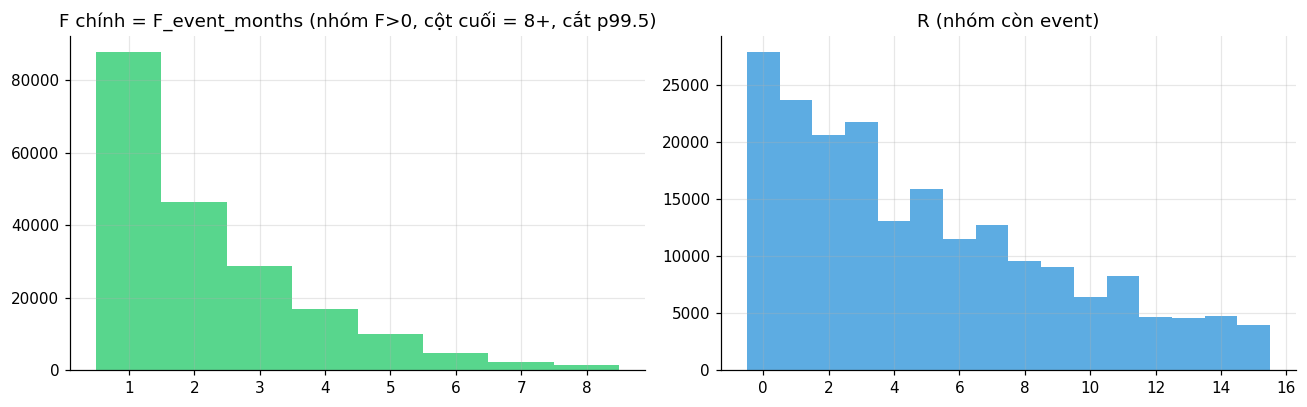

không giữ sản phẩm nào,False,True,All
có event (F>0),,,
False,504522,228444,732966
True,192017,6470,198487
All,696539,234914,931453


In [45]:
share_zero = (~rfm.has_event).mean()
print(f'Khách F = 0 (R không xác định): {share_zero:.1%}')
print('Trong nhóm F > 0 (median, P95, P99, max để nhìn outlier):')
print(rfm.loc[rfm.has_event, ['F_events', 'F_event_months', 'R']]
         .describe(percentiles=PCTS).round(2).rename(index=PCT_LABELS))

fpos = rfm.loc[rfm.has_event, 'F_event_months']
cap = int(fpos.quantile(0.995))                        # p99.5 của CHÍNH nhóm F>0
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
bins = np.arange(1, cap + 2) - 0.5
ax[0].hist(fpos.clip(upper=cap), bins=bins, color='#2ECC71', alpha=0.8)
ax[0].set_title(f'F chính = F_event_months (nhóm F>0, cột cuối = {cap}+, cắt p99.5)')
rbins = np.arange(-0.5, int(rfm.R.max()) + 1.5, 1)
ax[1].hist(rfm.R.dropna(), bins=rbins, color='#3498DB', alpha=0.8)
ax[1].set_title('R (nhóm còn event)')
plt.tight_layout(); plt.show()

zero_prod = rfm.M_n_products.eq(0)
display(pd.crosstab(rfm.has_event.rename('có event (F>0)'), zero_prod.rename('không giữ sản phẩm nào'), margins=True))

**Nhận xét về F (F chính = `F_event_months`):**

1. **F lệch phải, đa số khách mua ít.** Median là 2 và mean là 2,23. F = 1 chiếm 44,2% nhóm F > 0 (khoảng 87,8 nghìn khách), F ≤ 3 chiếm 82,2%, rồi giảm dần.
2. **Đuôi phải thưa, nhưng chưa thể kết luận là "không có outlier".** P95 = 5, P99 = 7, max = 14, tức max gấp đôi P99. Max 14 trên tối đa 16 cặp tháng nghĩa là có khách có event gần như mọi tháng; chưa biết đó là hoạt động thật hay cờ sản phẩm bật/tắt liên tục. Điểm này cần kiểm tra riêng. Rule tier có nhóm `5+` mở đầu trên nên không cần chặn ở P99.
3. **F thô cao hơn `F_event_months` chủ yếu ở đuôi.** Median bằng nhau (2 và 2), nhưng P95 là 7 so với 5 và max là 22 so với 14. Mục 5.1 cho thấy chọn nhầm F thô làm đổi tier ở 20,6% khách có event.

**Nhận xét về R:**

4. **R có trần 15, và trần này do cửa sổ dữ liệu, không phải outlier.** P99 = max = 15 vì dữ liệu chỉ có 17 tháng: event sớm nhất có thể quan sát là tháng thứ 2, nên R = 15 nghĩa là lần mua gần nhất đúng vào 02/2015. Mua trước đó thì không thể thấy event, nên không có giá trị R lớn hơn.
5. **R lệch phải nhẹ.** Median là 4 và mean là 4,91. Khoảng 25% khách mua trong 1 tháng gần nhất (R ≤ 1) và 75% có R ≤ 8. Mua gần đây (R = 0) là mốc cao nhất, sau đó giảm dần.
6. **Biểu đồ R có vài chỗ nhô lên** (khoảng R = 3, 5, 11), nghĩa là có những tháng nhiều event hơn các tháng lân cận. Cell này chưa cho biết vì sao; cần chuỗi event theo tháng và theo sản phẩm để trả lời.

**Nhận xét về bảng chéo (F = 0 gồm nhiều nhóm rất khác nhau):**

| | Đang giữ sản phẩm | Không giữ sản phẩm nào | Tổng |
|---|---|---|---|
| Không có event (F = 0) | 504.522 | 228.444 | 732.966 |
| Có event (F > 0) | 192.017 | 6.470 | 198.487 |
| Tổng | 696.539 | 234.914 | 931.453 |

7. **Trong nhóm F = 0, 504.522 khách (68,8%) đang giữ sản phẩm nhưng không có event.** Mục 5.3–5.4 đã kiểm chứng: 87,1% là khách cũ có sản phẩm từ trước cửa sổ (`fecha_alta` xác nhận 99,9% mở trước cửa sổ), 12,5% là khách mới mua ngay lúc mở nên event đầu tiên không được bắt. F = 0 chỉ có nghĩa là không thấy event trong dữ liệu, không có nghĩa là chưa từng mua.
8. **228.444 khách (31,2% nhóm F = 0) không giữ sản phẩm nào và không có event.** Phần lớn thuộc cohort 07/2015, tức khách đã đăng ký từ trước nhưng chưa có sản phẩm (mục 5.2, 5.4), chứ không phải khách đã rời bỏ.
9. **97,2% khách không giữ sản phẩm nào có F = 0.** Chỉ 6.470 khách có event mà cuối cùng không còn giữ sản phẩm nào (3,3% nhóm F > 0), là nhóm mua rồi bỏ hết.

**Quyết định cho bước tier:**

- **F:** dùng `F_event_months`, chia bằng rule 1, 2, 3-4, 5+ (44,2 / 23,4 / 23,0 / 9,3% nhóm F > 0). Không chia quantile vì mốc 20% và 40% cùng bằng 1.
- **R:** chia theo các mốc của nhóm F > 0 (25% = 1, median = 4, 75% = 8), ví dụ ≤1, 2-4, 5-8, 9+.
- **F = 0:** tách `No_Acquisition_Event` thành tối thiểu ba nhóm: khách cũ đang giữ sản phẩm, khách mới vào đã có sản phẩm (`opened_with_product`) và khách không giữ sản phẩm nào. Dùng các cột `arrival_type` và `why_no_event` ở mục 5.7. Không gộp chung.


### 7.2. Tenure có quyết định F không (exposure)
**Quyết định:** khách quan sát càng lâu càng có cơ hội mua thêm. Nếu F tăng mạnh theo tenure, F thô lẫn lộn "hoạt động" với "ở lâu" → cân nhắc chuẩn hóa `F / tenure` (nhóm tenure 0 không chia được) hoặc chia tier theo nhóm tenure. Lưu ý đây là tenure quan sát (tính từ đầu cửa sổ), không phải tenure thật; tenure thật (từ `fecha_alta`) ở 7.2b. Cohort 07/2015 có tenure quan sát đúng 10 tháng nên lẫn vào bucket 6-11; bảng thứ hai loại cohort để tách hai hiệu ứng. Bảng in thêm `F_months_tb` (F chính) để đối chiếu; các nhận xét dưới đây dùng `F_events`.

In [46]:
rfm['tenure_bucket'] = pd.cut(rfm.tenure_months, [-1, 0, 5, 11, 100],
                              labels=['0 (1 snapshot)', '1-5', '6-11', '12+'])
def exposure(d):
    return d.groupby('tenure_bucket', observed=True).agg(
        n_khach=('customer_id', 'size'), pct_F_duong=('has_event', 'mean'),
        F_events_tb=('F_events', 'mean'), F_months_tb=('F_event_months', 'mean'),
        M_san_pham_tb=('M_n_products', 'mean')).round(3)
print('Toàn bộ khách:'); display(exposure(rfm))
print('Không gồm cohort 07/2015:'); display(exposure(rfm[~rfm.is_onboarding_batch]))

Toàn bộ khách:


,n_khach,pct_F_duong,F_events_tb,F_months_tb,M_san_pham_tb
tenure_bucket,,,,,
0 (1 snapshot),4693,0.000,0.000,0.000,0.427
1-5,28949,0.429,0.741,0.576,1.057
6-11,271534,0.104,0.201,0.162,0.354
12+,626277,0.252,0.767,0.608,1.775


Không gồm cohort 07/2015:


,n_khach,pct_F_duong,F_events_tb,F_months_tb,M_san_pham_tb
tenure_bucket,,,,,
0 (1 snapshot),4693,0.000,0.000,0.000,0.427
1-5,28949,0.429,0.741,0.576,1.057
6-11,81290,0.231,0.465,0.368,0.903
12+,626277,0.252,0.767,0.608,1.775


**Nhận xét về tenure:**

1. **Nhóm `0 (1 snapshot)` có F = 0 theo định nghĩa.** Đây là 4.693 khách chỉ xuất hiện ở đúng tháng `as_of`, chưa có cặp tháng liền kề nào để tạo event. Họ không có R, và F = 0 ở đây không có nghĩa là họ không hoạt động.
2. **F không tăng theo tenure quan sát như ta tưởng.** Khách tenure quan sát 1-5 có 42,9% có event, cao hơn nhóm 12+ (25,2%). `F_events` trung bình của hai nhóm gần bằng nhau (0,741 và 0,767) dù nhóm 1-5 chỉ được quan sát tối đa 5 tháng. Nghĩa là khách mới mua dày hơn hẳn trong những tháng đầu.
3. **Giải thích khả dĩ, đã kiểm chứng một phần:** khách xuất hiện sau tháng đầu không đồng nhất. Cohort 07/2015 chủ yếu là khách đã đăng ký từ trước, không phải khách mới (mục 5.4). Nhóm "vào là đã có sản phẩm" (63.317 khách F = 0) thì là khách mới thật mua ngay lúc mở, nên event mua đầu tiên của họ không được bắt. Nhóm 12+ chứa phần lớn khách cũ có sản phẩm từ trước cửa sổ (87,1% nhóm F = 0 đang giữ sản phẩm). Vì vậy F thô lẫn lộn "mức hoạt động" với "giai đoạn vòng đời" và với việc event đầu tiên có bị che hay không. Chưa kiểm tra riêng cho nhóm 1-5; xem 5.5 và 7.2b.
4. **M tăng theo tenure ở nhóm dài hạn:** khách 12+ giữ trung bình 1,775 sản phẩm, so với khoảng 1 sản phẩm ở các nhóm ngắn hơn (1,057 và 0,903 khi loại cohort).

**Nhận xét về cohort 07/2015:**

5. **Cohort chiếm khoảng 70% nhóm 6-11.** Số khách thuộc cohort là 271.534 − 81.290 = 190.244 (khoảng 20,4% tổng khách). Cohort này có tenure quan sát đúng 10 tháng (tenure thật dài hơn nhiều, mục 5.4) nên toàn bộ rơi vào nhóm 6-11.
6. **Cohort kéo nhóm 6-11 xuống rất thấp.** Khi có cohort, nhóm này chỉ có 10,4% khách có event, `F_events` trung bình 0,201 và 0,354 sản phẩm. Khi loại cohort, các con số là 23,1%, 0,465 và 0,903. Suy ngược từ hai bảng, cohort có khoảng 5% khách có event, `F_events` trung bình khoảng 0,09 và khoảng 0,12 sản phẩm.
7. **Cohort gần như là khách "trống", đã xác nhận ở 5.2:** 90,4% cohort giữ 0 sản phẩm tại `as_of`, và cohort chiếm 73,2% trong 234.914 khách `n_products = 0`.

**Quyết định cho bước tier:**

- **Không so F/R thô giữa các nhóm tenure.** Nên chia tier F/R theo nhóm tenure. Chuẩn hóa `F / tenure` không phù hợp vì nhóm tenure 0 không chia được và tenure ngắn cho kết quả rất nhiễu.
- **Giữ cờ `is_onboarding_batch`, không xóa cohort.** Chia tier riêng cho cohort hoặc giữ làm biến ngoại sinh. Nếu gộp chung, cohort sẽ dồn vào nhóm R, F, M thấp nhất và làm lệch các mốc quantile.
- **Ghi chú khi trình bày:** `tenure_months` chỉ là độ dài quan sát (tính từ tháng đầu của dữ liệu). Khi cần tenure thật dùng `true_tenure_months` (từ `fecha_alta`, mục 5.4 và 7.2b).

### 7.2b. Tenure thật (từ `fecha_alta`) có quyết định F không?
**Kiểm tra gì → quyết định gì:** 7.2 dùng tenure quan sát (từ đầu cửa sổ). Ở đây dùng tenure thật. Bảng 1 chỉ gồm khách có mặt từ tháng đầu và mở trước cửa sổ: ai cũng được quan sát đủ 16 tháng, nên chênh lệch F chỉ do tenure thật. Bảng 2 gồm khách mới trong cửa sổ, theo tenure quan sát (bằng tenure thật). Nếu F đổi rõ theo tenure thật ở bảng 1 thì cần chia tier F theo nhóm tenure thật; nếu phẳng thì exposure không phải vấn đề và F chính dùng trực tiếp được.

In [47]:
TT_BINS, TT_LABELS = [-1, 11, 23, 47, 95, 1000], ['0-11', '12-23', '24-47', '48-95', '96+']
rfm['true_tenure_bucket'] = pd.cut(rfm.true_tenure_months, TT_BINS, labels=TT_LABELS)

def by_true_tenure(d):
    return d.groupby('true_tenure_bucket', observed=True).agg(
        n_khach=('customer_id', 'size'), pct_F_duong=('has_event', 'mean'),
        F_months_tb=('F_event_months', 'mean'), M_san_pham_tb=('M_n_products', 'mean'),
        pct_0_san_pham=('M_n_products', lambda s: s.eq(0).mean())).round(3)

print('Bảng 1: khách có mặt từ tháng đầu, mở trước cửa sổ (cùng độ dài quan sát), theo tenure thật:')
display(by_true_tenure(rfm[rfm.arrival_type.eq('legacy_from_start')]))
print('Bảng 2: khách mới trong cửa sổ, theo tenure quan sát:')
display(exposure(rfm[rfm.arrival_type.eq('new_in_window')]))

Bảng 1: khách có mặt từ tháng đầu, mở trước cửa sổ (cùng độ dài quan sát), theo tenure thật:


,n_khach,pct_F_duong,F_months_tb,M_san_pham_tb,pct_0_san_pham
true_tenure_bucket,,,,,
12-23,70490,0.218,0.476,1.208,0.045
24-47,156021,0.197,0.468,1.310,0.023
48-95,112327,0.211,0.511,1.578,0.026
96+,270951,0.285,0.716,2.288,0.066


Bảng 2: khách mới trong cửa sổ, theo tenure quan sát:


,n_khach,pct_F_duong,F_events_tb,F_months_tb,M_san_pham_tb
tenure_bucket,,,,,
0 (1 snapshot),4471,0.000,0.000,0.000,0.423
1-5,27588,0.427,0.739,0.573,1.057
6-11,100618,0.234,0.456,0.364,0.882
12+,13050,0.669,1.968,1.468,1.618


### 7.3. Monetary (a): số sản phẩm đang sở hữu
**Quyết định:** phân phối có đủ phân hóa để chia tier không. Nếu ~1-2 giá trị chiếm gần hết thì quantile tier sẽ trùng biên → dùng rule-based (0, 1, 2, 3+ sản phẩm).

In [48]:
mp = rfm.M_n_products.clip(upper=6).value_counts(normalize=True).sort_index()
mp.index = [str(int(i)) if i < 6 else '6+' for i in mp.index]
print('Phân phối số sản phẩm đang sở hữu (6+ gộp):'); print(mp.round(3).to_string())

Phân phối số sản phẩm đang sở hữu (6+ gộp):
0     0.252
1     0.486
2     0.129
3     0.051
4     0.031
5     0.019
6+    0.030


**Nhận xét:**

1. **Phân phối dồn vào 0 và 1.** 25,2% khách không giữ sản phẩm nào, 48,6% giữ đúng 1 sản phẩm, cộng lại khoảng 74% khách. Con số 25,2% khớp với 234.914 khách `n_products = 0` ở các bảng trước.
2. **M lệch phải mạnh.** Theo phân phối cộng dồn, median = 1, P75 = 2, P90 = 3, P95 = 5. Chỉ khoảng 13% khách giữ từ 3 sản phẩm trở lên và 3,0% giữ từ 6 sản phẩm trở lên.
3. **Không có nhóm `Unknown`.** Tỷ lệ các dòng cộng lại xấp xỉ 100%, và `M_n_products` không có NaN ở `as_of` này (NaN sản phẩm chỉ nằm ở 2015-01 đến 2015-06).
4. **Không thể chia tier M bằng quantile.** Median và P25 rơi vào 1 và 0, các mốc quantile sẽ trùng biên, và nhóm 1 sản phẩm một mình chiếm gần một nửa số khách.
5. **Cần lưu ý khi đọc M cao.** `M_n_products` là tổng 24 cờ sản phẩm. Khách giữ cả `prod_payroll` và `prod_pension_payroll` (48.309 khách, khoảng 5,2% tổng khách) bị tính thành 2 sản phẩm dù hai cờ này gần như là một. Điều này nghiêng về phía làm M cao lên một chút ở đúng nhóm khách này.

**Quyết định cho bước tier:** chia M bằng rule thay vì quantile: **0, 1, 2, 3+** (khoảng 25%, 49%, 13%, 13% khách). Nếu muốn tách thêm đuôi thì tách `3-4` và `5+`. Giữ nhóm 0 riêng, vì nó có nghĩa "biết chắc không giữ sản phẩm nào" và khác hẳn nhóm còn lại.

### 7.4. Monetary (b): `renta` (`household_income`)
`M_renta` là thu nhập của khách, không đo doanh thu hoặc lợi nhuận ngân hàng từ khách đó. Vì vậy nó là biến đối chiếu/bổ trợ, không thay thế mặc định cho M chính là `M_n_products`.

**Quyết định:** (i) `renta` có gần như cố định theo khách không → nếu có, lấy giá trị gần nhất là hợp lý; (ii) `renta` và số sản phẩm có tương quan không → nếu yếu, hai cách M sẽ cho tier khác hẳn nhau và cần so sánh độ ổn định.

In [49]:
print('Phân vị renta:'); print(rfm.M_renta.quantile([0, .05, .25, .5, .75, .95, .99, 1]).round(0).to_string())

# renta có ổn định theo khách không (mẫu 50k khách cho nhẹ)
rng = np.random.default_rng(0)
ids = rng.choice(rfm.customer_id.to_numpy(), size=min(50_000, len(rfm)), replace=False)
nun = (df.loc[df.customer_id.isin(ids), ['customer_id', 'household_income']].dropna()
       .groupby('customer_id').household_income.nunique())
print(f'\nKhách có >1 giá trị renta khác nhau (mẫu {len(ids):,}): {(nun > 1).mean():.1%}')

both = rfm.dropna(subset=['M_renta', 'M_n_products'])
rho = both[['M_renta', 'M_n_products']].corr(method='spearman').iloc[0, 1]
print(f'Spearman(renta, số sản phẩm): {rho:.3f}')
q = pd.qcut(both.M_renta, 5, duplicates='drop')
display(both.groupby(q, observed=True).M_n_products.mean().round(3).rename('so_san_pham_tb_theo_quintile_renta'))

Phân vị renta:
0.00        1203.0
0.05       40028.0
0.25       68494.0
0.50      101493.0
0.75      155546.0
0.95      310008.0
0.99      555606.0
1.00    28894396.0

Khách có >1 giá trị renta khác nhau (mẫu 50,000): 0.0%
Spearman(renta, số sản phẩm): 0.076


M_renta
(1202.729, 62363.22]        1.185
(62363.22, 87150.8]         1.295
(87150.8, 118702.028]       1.397
(118702.028, 174078.028]    1.534
(174078.028, 28894396.0]    1.638
Name: so_san_pham_tb_theo_quintile_renta, dtype: float32

**Nhận xét:**

1. **Renta cố định theo khách.** 0,0% khách trong mẫu có hơn 1 giá trị renta khác nhau, nên lấy "giá trị hợp lệ gần nhất" là hợp lý và không mất thông tin.
2. **Renta lệch phải rất mạnh và có outlier cực lớn.** Median là 101.493, P75 là 155.546, P95 là 310.008, P99 là 555.606, nhưng max là 28.894.396, gấp khoảng 52 lần P99 và khoảng 285 lần median. Chỉ vài khách ở đuôi có giá trị như vậy. Phía thấp nhất cũng có giá trị rất nhỏ (min = 1.203), chưa rõ đó là thu nhập thật hay lỗi nhập liệu.
3. **Renta có liên quan đến số sản phẩm nhưng rất yếu.** Spearman = 0,076. Số sản phẩm trung bình tăng đều qua 5 nhóm renta, từ 1,185 lên 1,638, tức nhóm renta cao nhất nhiều hơn nhóm thấp nhất khoảng 38%. Xu hướng đúng chiều nhưng mức chênh nhỏ, và có nhiều khách renta cao vẫn giữ ít sản phẩm.
4. **Hai cách đo M cho kết quả rất khác nhau.** Vì tương quan yếu, khách xếp tier cao theo renta thường không phải khách giữ nhiều sản phẩm. Renta phản ánh thu nhập hộ gia đình, không phải doanh thu ngân hàng từ khách, nên không thay `M_n_products` được.
5. **Bảng quintile chỉ đúng cho khách có renta.** Khoảng 24,6% khách thiếu renta và nhóm này khác nhóm còn lại (khách mới hơn, ít sản phẩm hơn), nên mối liên hệ ở điểm 3 chưa chắc áp dụng cho họ.

**Quyết định:**

- **M chính là `M_n_products`; `M_renta` chỉ là biến đối chiếu và bổ trợ.**
- **Nếu dùng `M_renta`:** chia tier bằng quantile thì outlier không ảnh hưởng vì quantile chỉ dựa vào thứ hạng. Nếu dùng giá trị số (clustering, chuẩn hóa) thì nên chặn ở P99 (555.606) hoặc lấy log, để vài giá trị cực lớn không kéo lệch thang đo.
- **Khách thiếu renta:** giữ `NaN` cùng cờ `renta_missing`, thành nhóm `Unknown` khi chia tier, không điền.
- **Khi so sánh tier theo hai cách M:** kiểm tra độ ổn định tier với cả hai bản.

### 7.5. Cohort onboarding 07/2015 so với còn lại
**Quyết định:** nếu cohort này khác hẳn về F, M thì tier chung sẽ bị nó kéo lệch → phân tầng theo `is_onboarding_batch` hoặc giữ làm biến ngoại sinh, không xóa.

In [50]:
display(rfm.groupby('is_onboarding_batch').agg(
    n_khach=('customer_id', 'size'), pct_F_duong=('has_event', 'mean'),
    F_events_tb=('F_events', 'mean'), F_months_tb=('F_event_months', 'mean'),
    M_san_pham_tb=('M_n_products', 'mean'), tenure_tb=('tenure_months', 'mean')).round(3))

,n_khach,pct_F_duong,F_events_tb,F_months_tb,M_san_pham_tb,tenure_tb
is_onboarding_batch,,,,,,
False,741209,0.255,0.728,0.577,1.643,14.43
True,190244,0.050,0.089,0.074,0.119,10.00


**Nhận xét:**

1. **Cohort chiếm khoảng 20,4% khách** (190.244 trên 931.453) nhưng hành vi khác hẳn phần còn lại.
2. **Cohort gần như không có event.** Chỉ 5,0% khách có event, so với 25,5% ở nhóm còn lại (thấp hơn khoảng 5 lần). F trung bình là 0,089, thấp hơn khoảng 8 lần. Cohort chiếm khoảng 20% số khách nhưng chỉ đóng góp khoảng 5% số khách F > 0.
3. **Cohort gần như không giữ sản phẩm nào.** Số sản phẩm trung bình chỉ 0,119, thấp hơn khoảng 14 lần. Vì số sản phẩm là số nguyên không âm nên tỷ lệ khách có ít nhất 1 sản phẩm không thể vượt 0,119, tức là **ít nhất khoảng 88% cohort có `n_products = 0`** (khoảng 168 nghìn khách). Con số này chiếm ít nhất khoảng 71% trong 234.914 khách `n_products = 0` của toàn bộ dữ liệu.
4. **Sự khác biệt không do tenure ngắn.** Cohort có tenure quan sát đúng 10 tháng, được quan sát khá lâu (tenure thật còn dài hơn, mục 5.4). Khách ngoài cohort thuộc nhóm tenure 6-11 (mục 7.2) có 23,1% khách có event và F trung bình 0,465, cao hơn hẳn cohort dù tenure tương đương. Vì vậy hành vi của cohort là đặc thù của cohort, không phải hệ quả của thời gian quan sát.
5. **Cohort là khách đã đăng ký từ trước, không phải khách mới.** `fecha_alta` cho thấy 91,1% cohort mở tài khoản từ trước 06/2015 (tập trung ở các tháng 10-12/2013 và 10-12/2014), chỉ 8,9% mở quanh tháng 7/2015. `ind_nuevo` trung bình 0,002 so với 0,046 ở nhóm còn lại, và 93,4% cohort không có sản phẩm lúc vào (mục 5.2, 5.4). Lý do họ xuất hiện đúng tháng 07/2015 (đổi cách trích dữ liệu hay đợt nhập hàng loạt) không xác định được từ dữ liệu.

**Tác động lên R, F, M:**

- **F, R:** cohort dồn phần lớn vào nhóm `F = 0` và `R = NaN`, làm tỷ lệ `No_Acquisition_Event` tăng lên.
- **M:** cohort dồn vào nhóm `M_n_products = 0`, nên 73,2% nhóm 0 (25,2% khách) là cohort chứ không phải khách "rời bỏ". Còn lại 62.923 khách 0 sản phẩm ngoài cohort, xem mục 5.6.

**Quyết định:** giữ cờ `is_onboarding_batch`, không xóa cohort, và dùng thêm `arrival_type` (mục 5.7) để phân biệt khách cũ từ đầu, khách đã đăng ký nhưng xuất hiện sau, và khách mới trong cửa sổ. Khi chia tier, có hai lựa chọn: chia tier riêng cho cohort, hoặc giữ cờ này làm biến ngoại sinh để các bước sau kiểm soát. Nếu gộp chung không kèm cờ, các mốc tier và phân bố của cả bảng sẽ bị cohort kéo lệch, và khi đọc kết quả bạn không nên coi 25,2% khách `n_products = 0` là nhóm bỏ đi.

## 8. Tổng kết

**Kết quả:** bảng RFM-proxy gồm **931.453 khách** tại `as_of` (tháng cuối của dữ liệu), dựng từ **561.710 event** 0→1 của 201.796 khách. Trong bảng RFM có 198.487 khách có event (21,3%) và 732.966 khách không có event (78,7%).

| | Định nghĩa | Phân phối chính | NaN có nghĩa gì | Fill NaN? |
|---|---|---|---|---|
| **R** | `as_of` trừ tháng của event gần nhất | Nhóm có event: median 4, P95 13, P99 = max = 15 (trần do cửa sổ 17 tháng, không phải outlier) | Khách không có event (78,7%), thiếu do **định nghĩa** | **Không.** Giữ NaN cùng cờ `has_event`, tier dùng nhóm `No_Acquisition_Event` |
| **F** | `F_event_months`: số tháng có event (F chính); `F_events`: tổng số event | Nhóm F>0: median 2, P95 5, P99 7, max 14 (`F_events`: P99 11, max 22). Lệch phải; max 14 trên tối đa 16 tháng chưa được kiểm tra có phải cờ bật/tắt không | Không có NaN, `0` là giá trị hợp lệ | **Không cần** |
| **M_n_products** | Số sản phẩm đang giữ ở `as_of` (M chính) | 0 sản phẩm: 25,2%, 1: 48,6%, 2: 12,9%, 3+: 13,1% | Không có NaN ở `as_of` này. `0` (biết chắc không giữ) khác `NaN` (chưa biết cờ) | **Không cần.** Nếu có NaN thì tạo nhóm `Unknown` |
| **M_renta** | Thu nhập hộ gia đình hợp lệ gần nhất (biến bổ trợ) | Median 101.493, P99 555.606, max 28.894.396. Tương quan với số sản phẩm rất yếu (Spearman 0,076) | Thiếu 24,59% khách, thiếu cả lịch sử. Nhóm thiếu là khách mới hơn, ít sản phẩm hơn | **Không fill ở bảng thô.** Chỉ khi model bắt buộc nhận số thì tạo cột riêng (median trên tập train + cờ `income_is_imputed`) |

**Những điểm cần nhớ khi dùng bảng này:**

1. **F = 0 không có nghĩa là chưa từng mua.** Chỉ là không thấy event 0→1 trong cửa sổ. Trong nhóm F = 0, 504.522 khách đang giữ sản phẩm: 87,1% là khách cũ có sản phẩm từ trước cửa sổ (`fecha_alta` xác nhận 99,9% mở trước cửa sổ), 12,5% là khách mới mua ngay lúc mở nên event đầu tiên không được bắt (cờ `opened_with_product`). Thêm 228.444 khách không giữ sản phẩm nào. Ba nhóm này khác nhau về ý nghĩa, không gộp chung.
2. **Cohort 07/2015 (190.244 khách, khoảng 20,4%) khác hẳn phần còn lại và không phải khách mới**: chỉ 5,0% có event (25,5% ở nhóm còn lại), giữ trung bình 0,119 sản phẩm (1,643 ở nhóm còn lại), 93,4% không có sản phẩm lúc vào. 91,1% mở tài khoản từ trước 06/2015, nên đây là khách đã đăng ký nhưng chưa có sản phẩm, lần đầu xuất hiện ở 07/2015. Cohort chiếm 73,2% nhóm 0 sản phẩm. Cần giữ cờ `is_onboarding_batch`, không gộp mù vào tier chung.
3. **Hai cờ payroll gần như là một** (98,8% mua cùng tháng). Dùng `F_event_months` thì F không bị tính trùng, còn `M_n_products` có thể tính dư 1 sản phẩm ở nhóm giữ cả hai cờ (48.309 khách).
4. **F và tenure quan sát lẫn lộn nhau.** Khách tenure quan sát 1-5 tháng có 42,9% khách có event, cao hơn nhóm 12+ (25,2%). Tenure thật (`true_tenure_months`, từ `fecha_alta`) có sẵn cho mọi khách; mục 7.2b cho biết có cần chia tier F theo tenure thật không.
5. **Đây là proxy từ cờ sở hữu theo tháng, không phải giao dịch thật.** "Một lần mua" nghĩa là một tháng có sản phẩm chuyển 0→1, và ta không biết ngày mua thực tế.

**Việc cho bước tier tiếp theo:**

- **R:** chia theo các mốc của nhóm có event (25% = 1, median = 4, 75% = 8), thêm nhóm `No_Acquisition_Event`.
- **F:** dùng `F_event_months`, chia bằng rule (1, 2, 3-4, 5+) cho 44,2 / 23,4 / 23,0 / 9,3% nhóm F>0. Không chia quantile vì mốc 20% và 40% cùng bằng 1. Không cần chặn ở P99 vì nhóm 5+ mở đầu trên.
- **F = 0 (`No_Acquisition_Event`):** tách tối thiểu thành khách cũ đang giữ sản phẩm, khách mới vào đã có sản phẩm (`opened_with_product`) và khách không giữ sản phẩm nào; dùng `arrival_type` và `why_no_event`.
- **Khách vào sau 07/2015 với 0 sản phẩm lúc vào** (25-62% số khách mới mỗi tháng): phân loại theo kết quả mục 5.5 trước khi chốt tier.
- **M:** chia bằng rule (0, 1, 2, 3+), giữ nhóm 0 riêng.
- **`M_renta`:** chỉ dùng để đối chiếu độ ổn định tier với `M_n_products`.

---
## 9. Lưu output

In [52]:
# Xem dữ liệu đúng như sẽ được lưu (chưa ghi gì ra đĩa)
rfm_out = rfm.drop(columns=['tenure_bucket', 'true_tenure_bucket'], errors='ignore')
ev_out = events.drop(columns=['month_idx', 'row'])

pd.set_option('display.max_columns', None, 'display.width', 200)

for name, d in [('rfm_proxy_raw', rfm_out), ('acquisition_events', ev_out)]:
    print(f'\n{"=" * 70}\n{name}: {d.shape[0]:,} dòng x {d.shape[1]} cột | {d.memory_usage(deep=True).sum() / 1e6:.0f} MB')
    print('=' * 70)
    info = pd.DataFrame({'dtype': d.dtypes.astype(str),
                         'n_missing': d.isna().sum(),
                         'pct_missing': (d.isna().mean() * 100).round(2),
                         'n_unique': d.nunique()})
    display(info)

# --- rfm: nhìn mẫu ---
print('\n10 dòng ngẫu nhiên của rfm_proxy_raw:')
display(rfm_out.sample(10, random_state=0))

print('\nMô tả các cột số:')
num_cols = ['F_events', 'F_event_months', 'R', 'M_n_products', 'M_renta',
            'tenure_months', 'true_tenure_months', 'n_prod_first']
display(rfm_out[num_cols].describe(percentiles=PCTS).round(2).rename(index=PCT_LABELS))

print('\nCác cột phân loại:')
for c in ['arrival_type', 'why_no_event']:
    print(f'\n{c}:')
    display(rfm_out[c].value_counts(dropna=False).to_frame('n').assign(pct=lambda x: (x.n / len(rfm_out) * 100).round(2)))
for c in ['has_event', 'renta_missing', 'is_onboarding_batch', 'zero_at_arrival',
          'opened_before_window', 'opened_with_product']:
    print(f'{c:22s}', rfm_out[c].value_counts(dropna=False).to_dict())

# --- events: nhìn mẫu ---
print('\n10 dòng ngẫu nhiên của acquisition_events:')
display(ev_out.sample(10, random_state=0))
print('\nSố event theo sản phẩm:')
display(ev_out['product'].value_counts().to_frame('n').assign(pct=lambda x: (x.n / len(ev_out) * 100).round(1)))
print('\nSố event theo tháng:')
display(ev_out.groupby(ev_out.record_date.dt.strftime('%Y-%m')).size().to_frame('n_event').T)

# --- kiểm tra chéo nhanh ---
print('\nKiểm tra nhất quán:')
print('customer_id duy nhất trong rfm       :', rfm_out.customer_id.is_unique)
print('R thiếu đúng bằng nhóm không có event:', rfm_out.R.isna().eq(~rfm_out.has_event).all())
print('F_event_months <= F_events           :', rfm_out.F_event_months.le(rfm_out.F_events).all())
print('why_no_event chỉ có ở F=0 & có SP    :',
      rfm_out.why_no_event.notna().eq((~rfm_out.has_event) & rfm_out.M_n_products.gt(0)).all())
print('opened_with_product => arrival_type  :',
      rfm_out.loc[rfm_out.opened_with_product, 'arrival_type'].eq('new_in_window').all())
print('khách có event trong rfm khớp bảng event:',
      rfm_out.has_event.sum() <= ev_out.customer_id.nunique())


rfm_proxy_raw: 931,453 dòng x 20 cột | 170 MB


,dtype,n_missing,pct_missing,n_unique
customer_id,int32,0,0.00,931453
M_n_products,float32,0,0.00,16
F_events,int32,0,0.00,23
F_event_months,int32,0,0.00,15
M_renta,float32,229018,24.59,516837
has_event,bool,0,0.00,2
R,float64,732966,78.69,16
tenure_months,int32,0,0.00,17
renta_missing,bool,0,0.00,2
as_of_month,datetime64[us],0,0.00,1



acquisition_events: 561,710 dòng x 4 cột | 45 MB


,dtype,n_missing,pct_missing,n_unique
customer_id,int32,0,0.0,201796
record_date,datetime64[ns],0,0.0,16
product,object,0,0.0,24
is_onboarding_batch,bool,0,0.0,2



10 dòng ngẫu nhiên của rfm_proxy_raw:


...


Số event theo sản phẩm:


,n,pct
product,,
prod_direct_debit,153146,27.3
prod_pension_payroll,84709,15.1
prod_payroll,73753,13.1
prod_credit_card,69118,12.3
prod_current_account,69103,12.3
prod_payroll_account,37098,6.6
prod_eaccount,26361,4.7
prod_long_term_deposit,12659,2.3
prod_taxes,9234,1.6



Số event theo tháng:


record_date,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05
n_event,31372,31948,30427,26311,41745,33362,29490,35696,39803,35215,42353,30956,49024,35203,32962,35843



Kiểm tra nhất quán:
customer_id duy nhất trong rfm       : True
R thiếu đúng bằng nhóm không có event: True
F_event_months <= F_events           : True
why_no_event chỉ có ở F=0 & có SP    : True
opened_with_product => arrival_type  : True
khách có event trong rfm khớp bảng event: True


In [51]:
assert events.customer_id.isin(window.customer_id).all()
assert events['product'].isin(PRODUCT_COLS).all() and events.record_date.le(LAST_MONTH).all()
assert 'F' not in rfm.columns and {'F_events', 'F_event_months'} <= set(rfm.columns)
assert {'arrival_type', 'opened_with_product', 'true_tenure_months', 'why_no_event'} <= set(rfm.columns)

os.makedirs(WORK_DIR, exist_ok=True)
events.drop(columns=['month_idx', 'row']).to_parquet(os.path.join(WORK_DIR, 'acquisition_events.parquet'), index=False)
rfm.drop(columns=['tenure_bucket', 'true_tenure_bucket'], errors='ignore').to_parquet(
    os.path.join(WORK_DIR, 'rfm_proxy_raw.parquet'), index=False)
print(f'Đã lưu: {len(events):,} event | {len(rfm):,} RFM '
      f'(as_of={AS_OF.date()}, giữ NaN + cờ) → {WORK_DIR}')

Đã lưu: 561,710 event | 931,453 RFM (as_of=2016-05-28, giữ NaN + cờ) → /kaggle/working/
